<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e0f7fa; font-size: 2.2em; font-weight: 700; margin: 0 0 8px 0; letter-spacing: 1px;"># 🍷 UTS Machine learning Wine Quality Classification 
</h1>
  <div style="display: flex; justify-content: center; gap: 15px; flex-wrap: wrap;">
    <span style="background: rgba(255,255,255,0.1); color: #b2ebf2; padding: 5px 14px; border-radius: 20px; font-size: 0.85em;">Yudhoro Kunto Wibisono</span>
    <span style="background: rgba(255,255,255,0.1); color: #b2ebf2; padding: 5px 14px; border-radius: 20px; font-size: 0.85em;">2304010031</span>
    <span style="background: rgba(255,255,255,0.1); color: #b2ebf2; padding: 5px 14px; border-radius: 20px; font-size: 0.85em;">Staterkom</span>
    
  </div>
</div>

> **Alur Pengerjaan:**  
> `Load Data` → `EDA` → `Data Preprocessing` → `Imbalanced Target` → `SMOTE` → `Scaling` → `Modeling` → `Tuning` → `Evaluasi`

---
##  Langkah 0 — Import Library

In [1]:
# ── Library Dasar ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Preprocessing & Validasi ─────────────────────────────────
from sklearn.preprocessing   import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold,
    train_test_split, GridSearchCV,
    RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.inspection import permutation_importance

# ── Scikit-learn: Model ────────────────────────────────────────────────────
from sklearn.ensemble  import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import SVC

# ── Imbalanced-learn: SMOTE ────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline      import Pipeline as ImbPipeline

# ── Boosting: XGBoost & LightGBM ──────────────────────────────────────────
import xgboost  as xgb
import lightgbm as lgb

# ── Statistik ─────────────────────────────────────────────────────────────
from scipy import stats as sp_stats
from scipy.stats import shapiro, kruskal, chi2_contingency

# ── Konfigurasi Tampilan ───────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

SEED = 42
np.random.seed(SEED)
print('✅ Semua library berhasil diimport.')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')


✅ Semua library berhasil diimport.
   pandas 2.3.3 | numpy 1.26.4


---
##  Langkah 1 — Load Data




In [2]:
# ── Path file ──────────────────────────────────────────────────────────────

TRAIN_PATH = r'd:\download\data_training.csv'
TEST_PATH  = r'd:\download\data_testing.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print('=' * 60)
print(f'  Training  : {train_df.shape[0]:>5} baris × {train_df.shape[1]:>2} kolom')
print(f'  Testing   : {test_df.shape[0]:>5} baris × {test_df.shape[1]:>2} kolom')
print('=' * 60)
print(f'\nKolom: {list(train_df.columns)}')


  Training  :   857 baris × 13 kolom
  Testing   :   286 baris × 12 kolom

Kolom: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


> **📌 Penjelasan Output:**  
>Berdasarkan output yang tercetak di terminal, kita dapat melihat karakteristik dataset yang akan diproses. Data latih diketahui memiliki 857 baris sampel dan 13 kolom, sedangkan data uji memiliki proporsi lebih kecil yakni 286 baris dan hanya 12 kolom

In [3]:
train_df.head()


=== Preview Data Training ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3000,0.7400,0.0800,1.7000,0.0940,10.0000,45.0000,0.9958,3.2400,0.5000,9.8000,5,1366
1,8.1000,0.5750,0.2200,2.1000,0.0770,12.0000,65.0000,0.9967,3.2900,0.5100,9.2000,5,103
2,10.1000,0.4300,0.4000,2.6000,0.0920,13.0000,52.0000,0.9983,3.2200,0.6400,10.0000,7,942
3,12.9000,0.5000,0.5500,2.8000,0.0720,7.0000,24.0000,1.0001,3.0900,0.6800,10.9000,6,811
4,8.4000,0.3600,0.3200,2.2000,0.0810,32.0000,79.0000,0.9964,3.3000,0.7200,11.0000,6,918


In [4]:
test_df.head()


=== Preview Data Testing ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8000,0.6100,0.0400,1.5000,0.0570,5.0000,10.0000,0.9952,3.4200,0.6000,9.5000,222
1,6.9000,0.8400,0.2100,4.1000,0.0740,16.0000,65.0000,0.9984,3.5300,0.7200,9.2333,1514
2,7.0000,0.5800,0.1200,1.9000,0.0910,34.0000,124.0000,0.9956,3.4400,0.4800,10.5000,417
3,7.8000,0.4800,0.6800,1.7000,0.4150,14.0000,32.0000,0.9966,3.0900,1.0600,9.1000,754
4,12.5000,0.6000,0.4900,4.3000,0.1000,5.0000,14.0000,1.0010,3.2500,0.7400,11.9000,516


In [5]:
# ── Tipe data & info kolom 
train_df.info()
test_df.info()


=== Info Data Training ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

=== Info Data Testing ===
<class 'pandas.core.fram

> **📌 Penjelasan Output:**  
> berasarkan output terlihat bahwa seluruh kolom sudah berupa tipe data numerik (kombinasi angka desimal float64 dan angka bulat int64), sehingga tidak diperlukan lagi proses konversi teks ke angka (encoding)

In [6]:
#  Ringkasan statistik awal 
print('=== Statistik Deskriptif — Data Training ===')
feature_cols = [c for c in train_df.columns if c not in ['quality', 'Id']]
train_df[feature_cols + ['quality']].describe().T.round(4)


=== Statistik Deskriptif — Data Training ===


,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0000,8.2620,1.7020,4.6000,7.1000,7.9000,9.1000,15.6000
volatile acidity,857.0000,0.5294,0.1792,0.1200,0.3950,0.5200,0.6400,1.5800
citric acid,857.0000,0.2674,0.1951,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,857.0000,2.5062,1.2935,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,857.0000,0.0868,0.0487,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,857.0000,15.7830,10.3004,1.0000,7.0000,14.0000,21.0000,68.0000
total sulfur dioxide,857.0000,45.9784,31.6921,6.0000,21.0000,38.0000,63.0000,278.0000
density,857.0000,0.9967,0.0019,0.9901,0.9955,0.9967,0.9978,1.0032
pH,857.0000,3.3131,0.1521,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,857.0000,0.6567,0.1674,0.3900,0.5500,0.6200,0.7300,2.0000


> **📌 Penjelasan Output:**  
>Dari hasil tersebut, terlihat bahwa variabel target quality memiliki rentang nilai antara 3 hingga 8 dengan rata-rata 5.65, yang mengindikasikan bahwa mayoritas data berada pada kategori kualitas menengah. Secara teknis, terdapat perbedaan skala yang sangat mencolok antar fitur, misalnya antara density yang bernilai sekitar 0.99 dengan total sulfur dioxide yang mencapai nilai maksimal hingga 278; hal ini menandakan bahwa dataset kamu memerlukan proses feature scaling agar fitur dengan angka besar tidak mendominasi model secara tidak adil. Selain itu, adanya selisih yang jauh antara nilai kuartil ke-3 (75%) dan nilai maksimal pada fitur seperti total sulfur dioxide dan residual sugar menjadi indikator kuat adanya outliers atau pencilan ekstrem yang perlu diperhatikan karena berpotensi memengaruhi akurasi prediksi model nantinya.

---
## 🔍 Langkah 2 — Exploratory Data Analysis (EDA)




In [7]:
# ── Distribusi target awal ────────────────────────────────────────────────
print('=== Distribusi Target (quality) ===')
print(train_df['quality'].value_counts().sort_index())
print(f'\nJumlah kelas unik: {train_df["quality"].nunique()}')
print(f'Range quality     : {train_df["quality"].min()} – {train_df["quality"].max()}')


=== Distribusi Target (quality) ===
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Jumlah kelas unik: 6
Range quality     : 3 – 8


> **📌 Penjelasan Output:**  
> berdasarkan ouput distribusi frekuensi dari variabel target quality, yang mencakup enam kelas unik dalam rentang skor 3 hingga 8. Terlihat dengan jelas adanya fenomena ketimpangan data atau class imbalance, di mana kategori 5 dan 6 sangat mendominasi dataset dengan total akumulasi lebih dari 700 sampel, sementara kategori ekstrem seperti skor 3 dan 8 hanya memiliki jumlah sampel yang sangat sedikit, yakni masing-masing 6 dan 13 data.

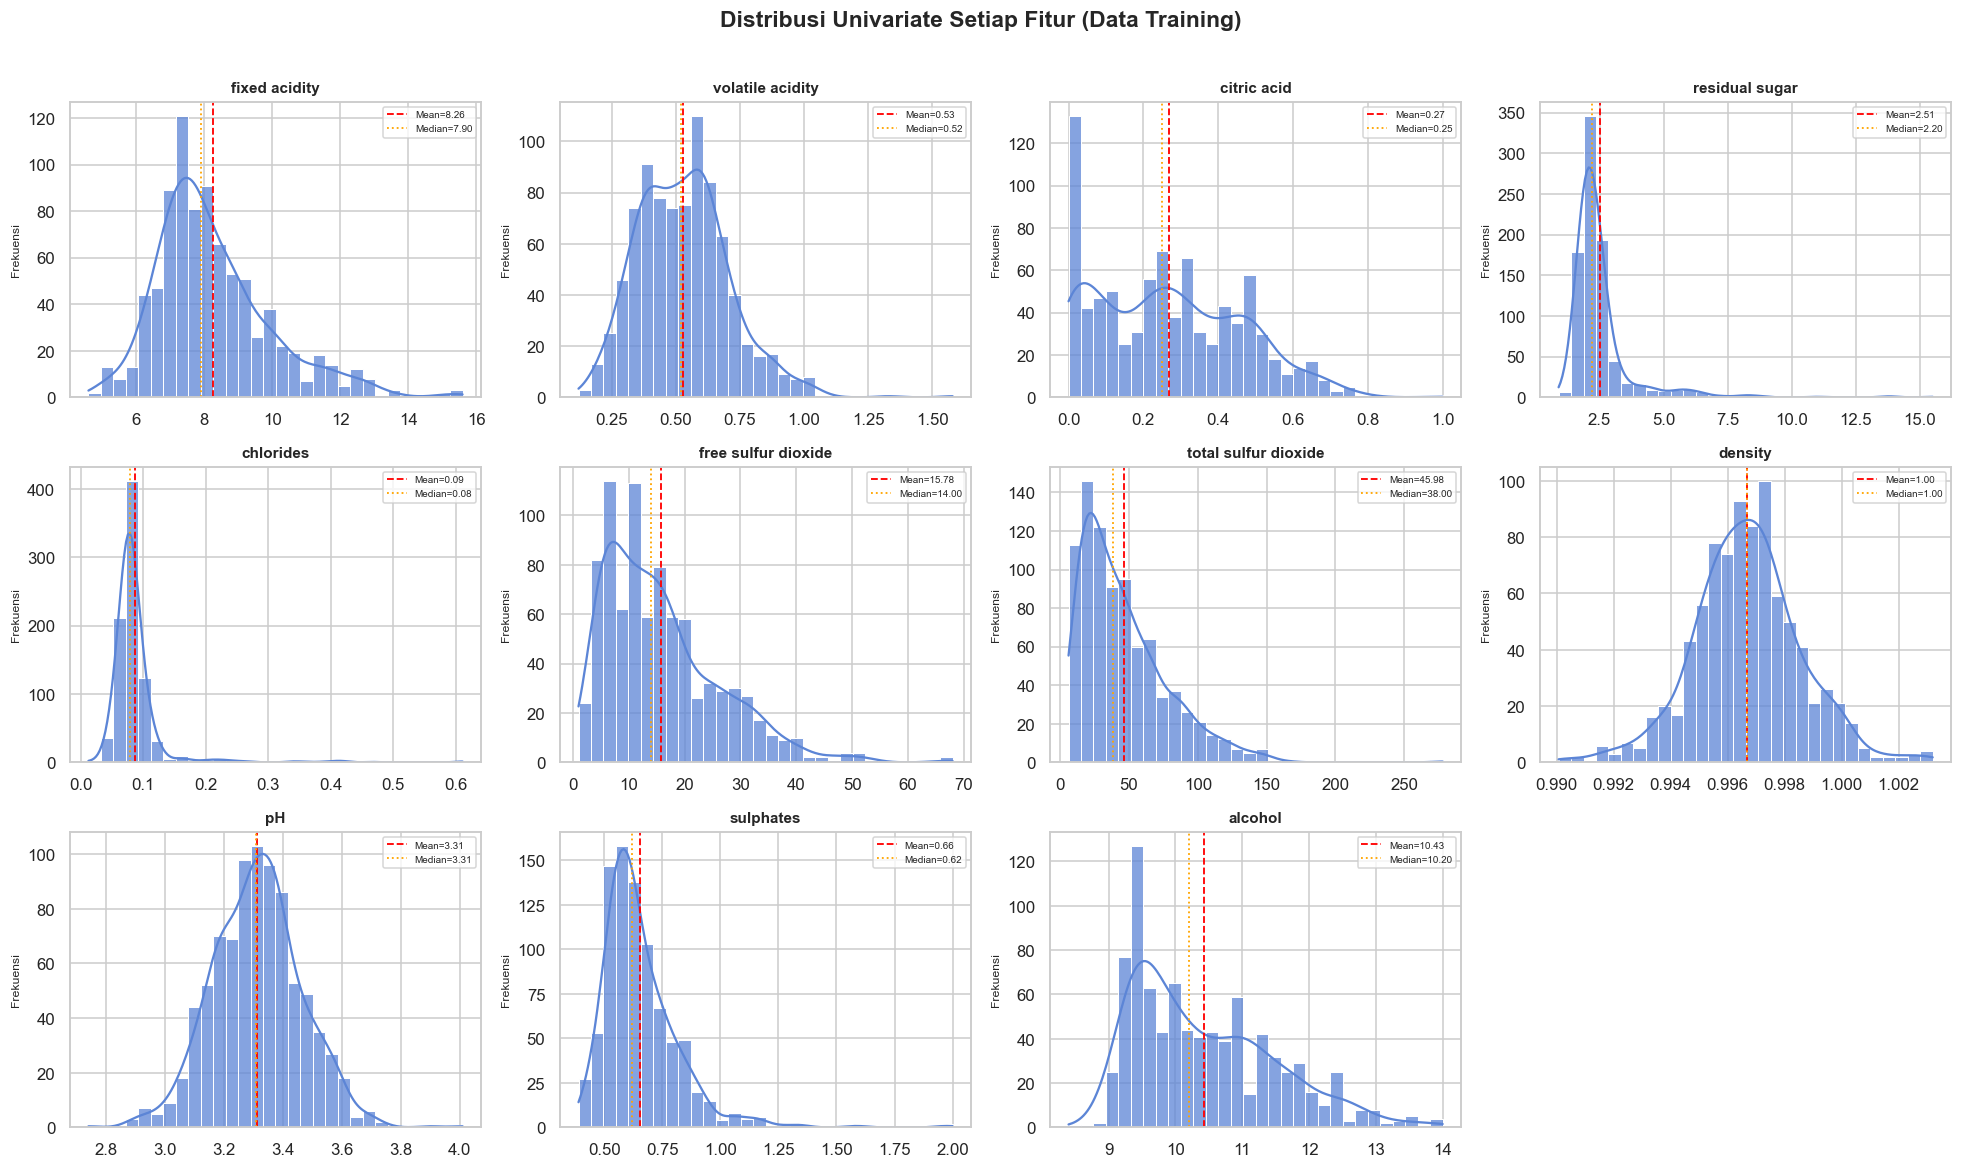

In [8]:
# ── Histogram + KDE untuk setiap fitur ───────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(train_df[col], kde=True, ax=ax, color='#5C85D6', bins=30, alpha=0.75)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frekuensi', fontsize=8)
    # Tambahkan garis mean & median
    mean_val   = train_df[col].mean()
    median_val = train_df[col].median()
    ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.2, label=f'Median={median_val:.2f}')
    ax.legend(fontsize=6.5, loc='upper right')

# Sembunyikan axes kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Univariate Setiap Fitur (Data Training)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi tersebut menampilkan distribusi univariate (satu variabel) dari setiap fitur numerik dalam dataset menggunakan kombinasi histogram dan kurva KDE (Kernel Density Estimation). Secara umum, sebagian besar fitur seperti residual sugar, chlorides, free sulfur dioxide, dan sulphates menunjukkan pola distribusi right-skewed (miring ke kanan), di mana terdapat ekor panjang ke arah nilai yang lebih tinggi yang mengindikasikan adanya banyak nilai pencilan atau outliers. Hal ini dipertegas dengan posisi garis mean (garis merah putus-putus) yang berada di sebelah kanan garis median (garis oranye titik-titik), menunjukkan bahwa nilai rata-rata ditarik ke atas oleh angka-angka ekstrem tersebut. Sebaliknya, fitur seperti pH dan density menunjukkan karakteristik distribusi yang lebih simetris atau mendekati distribusi normal, di mana nilai mean dan median cenderung berhimpit di tengah puncak data.

In [9]:
# ── Skewness & Kurtosis ───────────────────────────────────────────────────
stats_df = pd.DataFrame({
    'Mean'     : train_df[feature_cols].mean(),
    'Std'      : train_df[feature_cols].std(),
    'Min'      : train_df[feature_cols].min(),
    'Max'      : train_df[feature_cols].max(),
    'Skewness' : train_df[feature_cols].skew(),
    'Kurtosis' : train_df[feature_cols].kurt(),
}).round(4)

# Tandai fitur highly skewed
stats_df['Skew Level'] = stats_df['Skewness'].abs().apply(
    lambda x: '🔴 High' if x > 1 else ('🟡 Moderate' if x > 0.5 else '🟢 Low')
)
print('=== Statistik Distribusi Fitur ===')
print(stats_df.to_string())


=== Statistik Distribusi Fitur ===
                        Mean     Std    Min      Max  Skewness  Kurtosis  Skew Level
fixed acidity         8.2620  1.7020 4.6000  15.6000    1.0904    1.6577      🔴 High
volatile acidity      0.5294  0.1792 0.1200   1.5800    0.6703    1.4727  🟡 Moderate
citric acid           0.2674  0.1951 0.0000   1.0000    0.3824   -0.6484       🟢 Low
residual sugar        2.5062  1.2935 0.9000  15.5000    4.5359   30.2467      🔴 High
chlorides             0.0868  0.0487 0.0120   0.6110    6.0903   48.2307      🔴 High
free sulfur dioxide  15.7830 10.3004 1.0000  68.0000    1.2041    1.7305      🔴 High
total sulfur dioxide 45.9784 31.6921 6.0000 278.0000    1.4632    3.7807      🔴 High
density               0.9967  0.0019 0.9901   1.0032    0.0834    0.9738       🟢 Low
pH                    3.3131  0.1521 2.7400   4.0100    0.1156    0.6644       🟢 Low
sulphates             0.6567  0.1674 0.3900   2.0000    2.4022   11.6722      🔴 High
alcohol              10.4303  

> **📌 Penjelasan Output:**  
>Tabel statistik tersebut memberikan penjelasan  mengenai bentuk distribusi data kamu, di mana fokus utamanya terletak pada kolom Skewness untuk mengukur asimetri dan Kurtosis untuk mendeteksi keberadaan pencilan ekstrem. Fitur-fitur seperti chlorides dan residual sugar menjadi "bintang utama" dalam hal anomali karena memiliki level High Skew (indikator merah) yang sangat tinggi, masing-masing sebesar 6.09 dan 4.53, disertai nilai Kurtosis yang fantastis (48.23 dan 30.24). Angka-angka ini adalah sinyal kuat bahwa distribusi data tersebut sangat miring ke kanan (right-skewed) dan memiliki "ekor" yang sangat panjang berisi pencilan yang bisa mengganggu performa model.

Di sisi lain, fitur seperti density, pH, dan citric acid tampak jauh lebih "sopan" dengan label Low Skew (hijau), yang menandakan distribusinya cukup simetris dan mendekati distribusi normal.

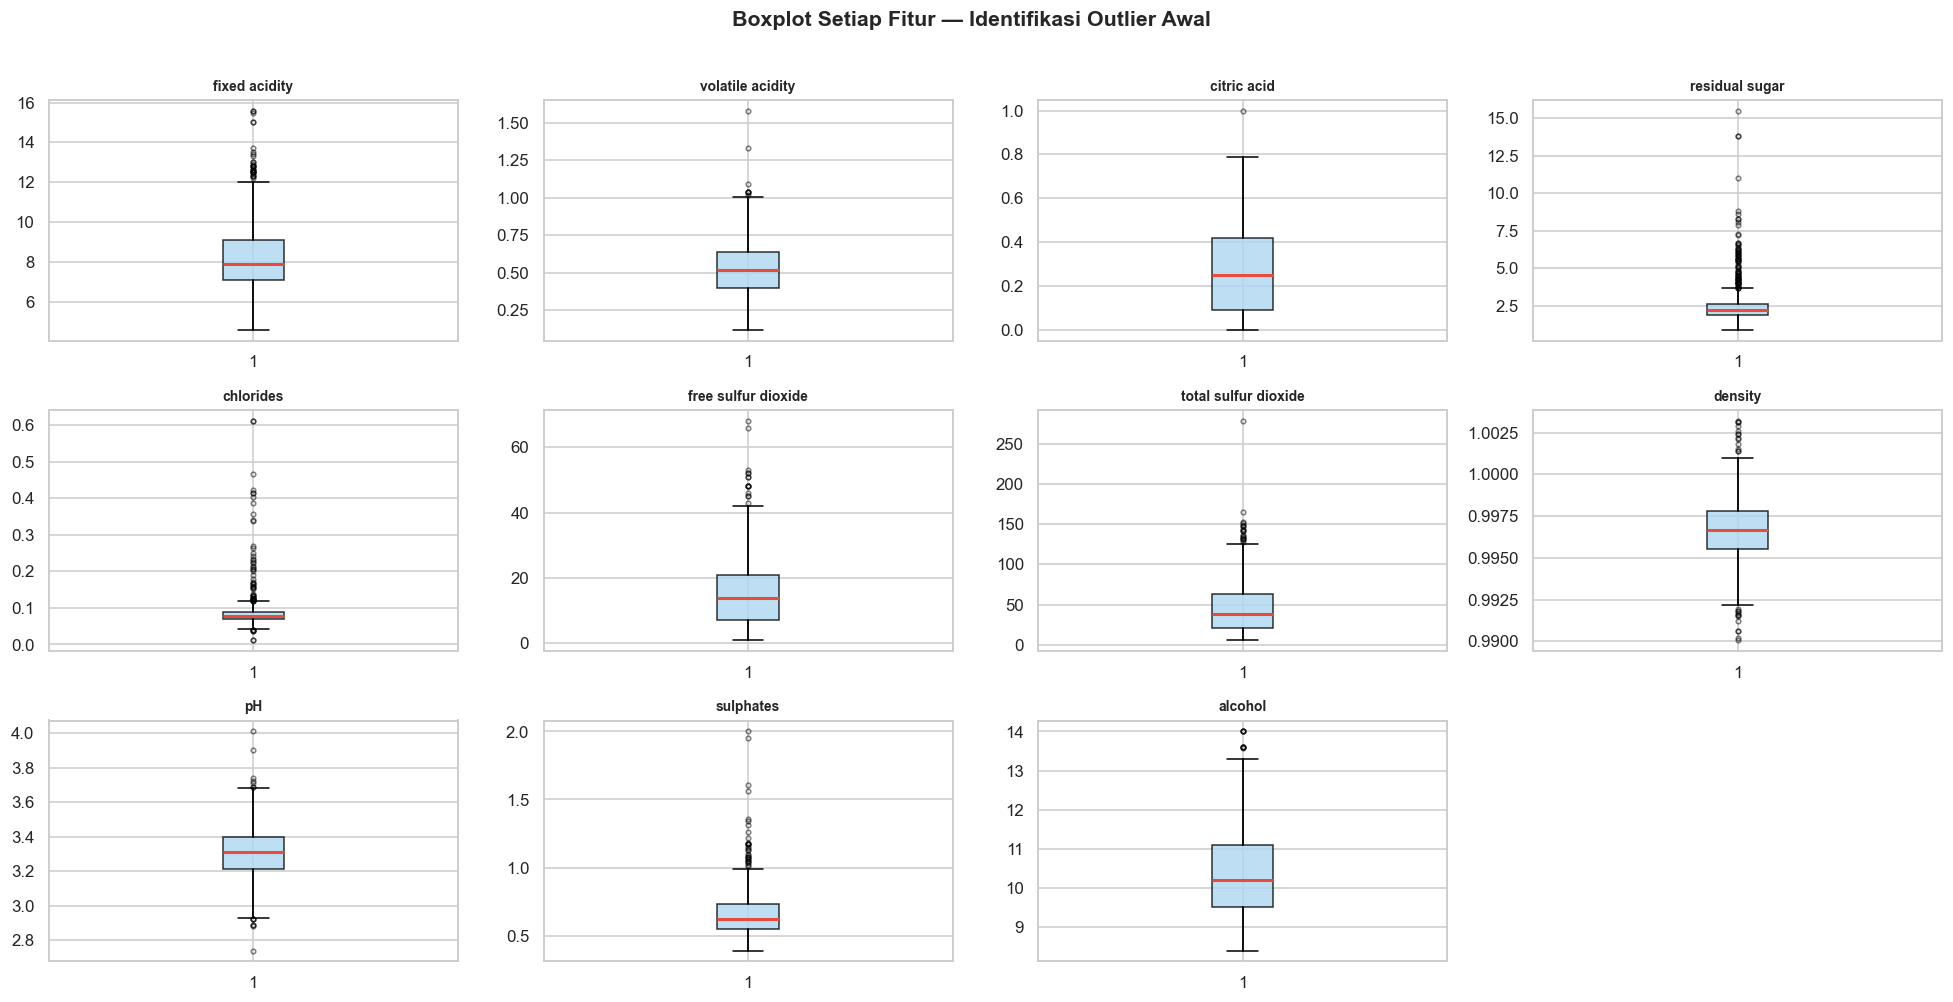

In [10]:
# ── Boxplot semua fitur (sebelum scaling) ─────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    bp = ax.boxplot(train_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', alpha=0.8),
                    medianprops=dict(color='#E74C3C', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5, color='gray'))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Setiap Fitur — Identifikasi Outlier Awal',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi tersebut menyajikan rangkaian boxplot yang berfungsi untuk mengidentifikasi distribusi data serta keberadaan outlier (pencilan) pada setiap fitur secara visual. Secara teknis, hampir seluruh variabel dalam dataset ini memiliki pencilan, yang ditandai dengan munculnya titik-titik kecil di luar garis "whisker" (kumis) atas maupun bawah. Fitur seperti residual sugar, chlorides, dan total sulfur dioxide menunjukkan kumpulan outlier yang sangat ekstrem di sisi atas, yang secara langsung mengonfirmasi temuan statistik sebelumnya mengenai tingkat skewness dan kurtosis yang tinggi. Sebaliknya, fitur seperti pH dan density memperlihatkan outlier di kedua ujung (atas dan bawah), namun dengan sebaran yang lebih simetris. Keberadaan pencilan yang masif ini memberikan sinyal penting bahwa data memerlukan penanganan khusus, baik melalui teknik clipping, penghapusan, maupun transformasi

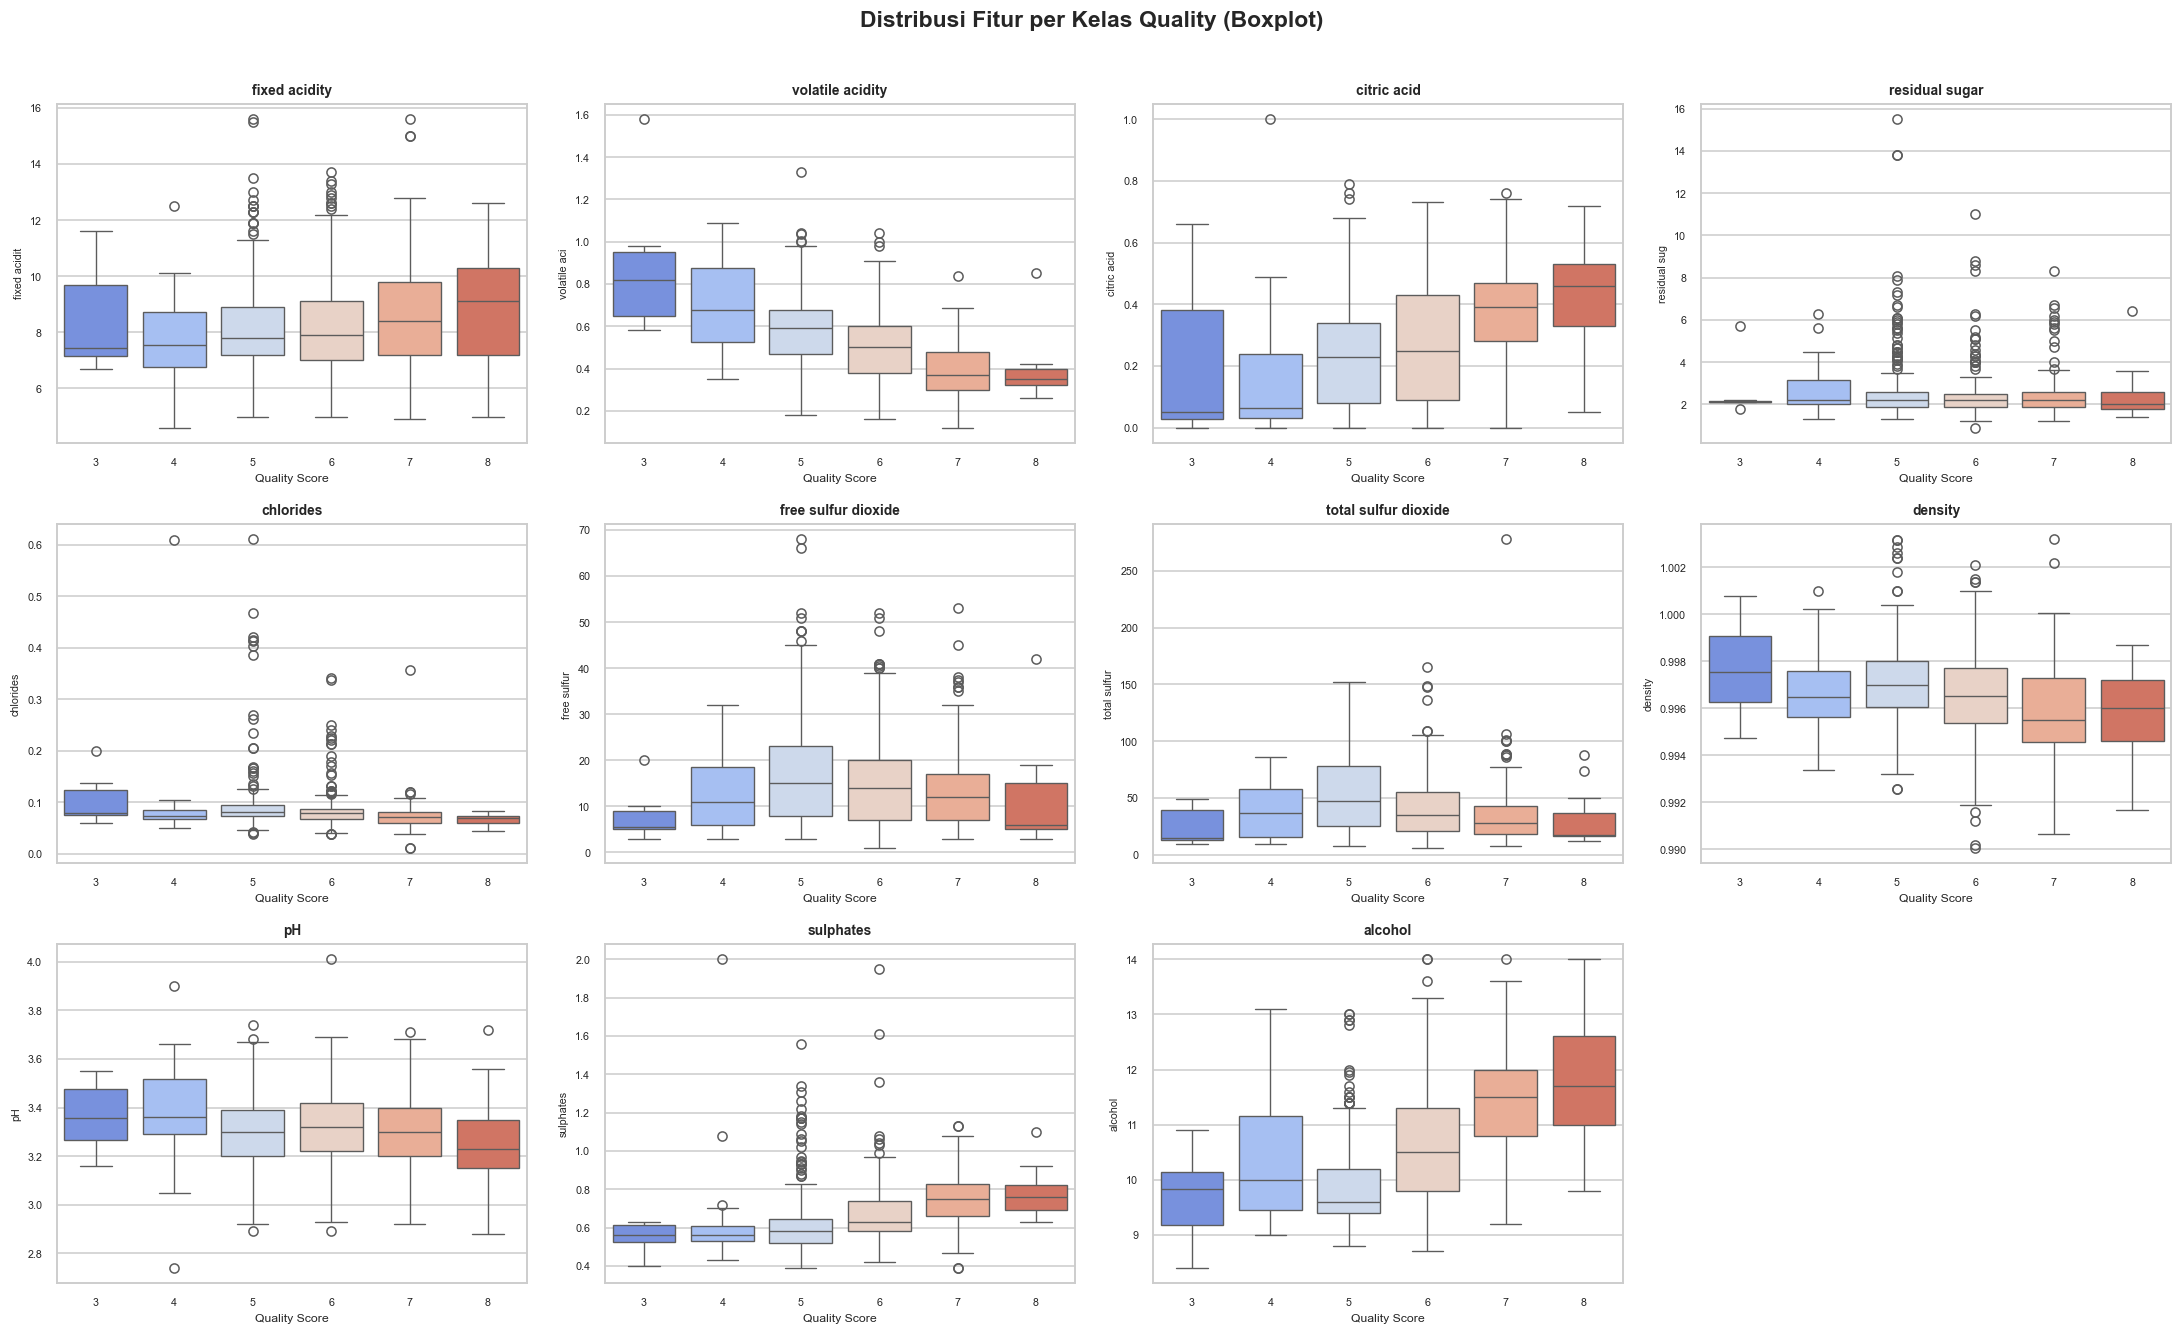

💡 Fitur dengan variasi besar antar kelas → diskriminatif untuk model


In [11]:
# ── Boxplot tiap fitur dikelompokkan per kelas quality ────────────────────
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))
quality_classes = sorted(train_df['quality'].unique())
palette = sns.color_palette('coolwarm', len(quality_classes))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(
        data=train_df, x='quality', y=col,
        palette=palette, ax=ax, linewidth=0.9,
        order=quality_classes
    )
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Quality Score', fontsize=8)
    ax.set_ylabel(col[:12], fontsize=7)
    ax.tick_params(axis='both', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur per Kelas Quality (Boxplot)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('💡 Fitur dengan variasi besar antar kelas → diskriminatif untuk model')


> **📌 Penjelasan Output:**  
>Grafik Bivariate Analysis ini memetakan hubungan antara fitur-fitur kimiawi dengan variabel target Quality Score, memberikan gambaran visual tentang bagaimana karakteristik fisikokimia memengaruhi persepsi kualitas wine. Tren yang paling mendominasi terlihat pada fitur alcohol, di mana terdapat korelasi positif yang sangat kuat; median kadar alkohol meningkat secara konsisten seiring dengan kenaikan skor kualitas, menunjukkan bahwa alkohol adalah salah satu prediktor paling signifikan. Sebaliknya, volatile acidity menunjukkan tren penurunan yang sangat jelas (korelasi negatif), di mana wine berkualitas tinggi (skor 7-8) memiliki tingkat keasaman volatil yang rendah, yang selaras dengan teori bahwa kadar asam volatil yang tinggi dapat memberikan aroma cuka yang merusak kualitas. Fitur pendukung lain seperti citric acid dan sulphates juga menunjukkan tren peningkatan yang moderat terhadap kualitas. Walaupun pencilan (outliers) masih tersebar di hampir semua kelas

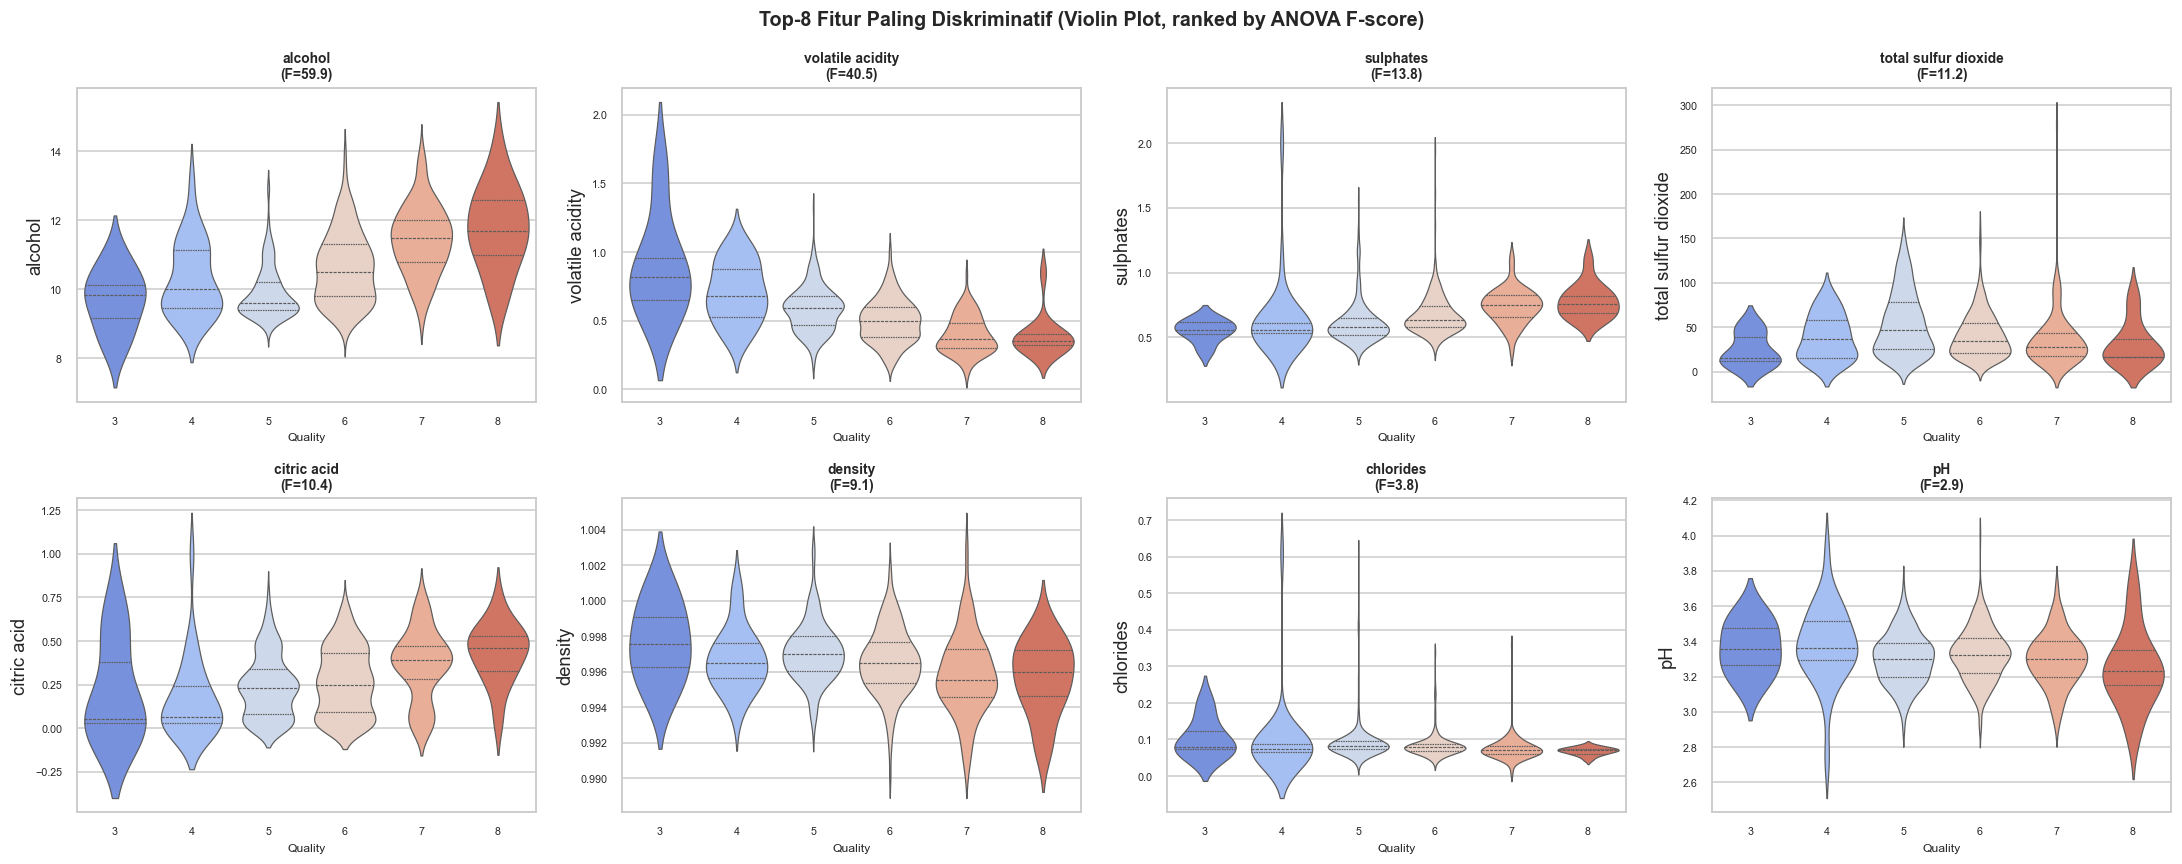

In [12]:
# ── Violin Plot: fitur paling diskriminatif ───────────────────────────────
# Hitung ANOVA F-score untuk ranking fitur
from sklearn.feature_selection import f_classif

X_temp = train_df[feature_cols].fillna(train_df[feature_cols].median())
y_temp = train_df['quality'].values
f_scores, p_values = f_classif(X_temp, y_temp)

top_n = 8
top_idx  = np.argsort(f_scores)[::-1][:top_n]
top_feats = [feature_cols[i] for i in top_idx]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(top_feats):
    ax = axes[i]
    sns.violinplot(
        data=train_df, x='quality', y=col,
        palette='coolwarm', ax=ax, inner='quartile',
        order=quality_classes, linewidth=0.8
    )
    ax.set_title(f'{col}\n(F={f_scores[feature_cols.index(col)]:.1f})',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Quality', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle(f'Top-{top_n} Fitur Paling Diskriminatif (Violin Plot, ranked by ANOVA F-score)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi tersebut menampilkan Top-8 Fitur Paling Diskriminatif menggunakan Violin Plot, yang menunjukkan rentang data, tetapi juga distribusi kepadatan (density) melalui lebar bentuk "biola"-nya. Fitur-fitur ini diurutkan berdasarkan ANOVA F-score, sebuah metrik statistik yang mengukur seberapa baik suatu fitur mampu membedakan rata-rata antar kelas kualitas; semakin tinggi skor $F$, semakin kuat fitur tersebut dalam memisahkan kategori wine. Alcohol (F=59.9) muncul sebagai fitur paling berpengaruh dengan tren positif yang sangat jelas, di mana "perut" biola bergeser ke atas seiring meningkatnya kualitas wine. Sebaliknya, volatile acidity (F=40.5) menunjukkan tren negatif yang tajam, menandakan bahwa wine premium (skor 7-8) secara konsisten memiliki distribusi keasaman volatil yang lebih rendah dan lebih terkonsentrasi.

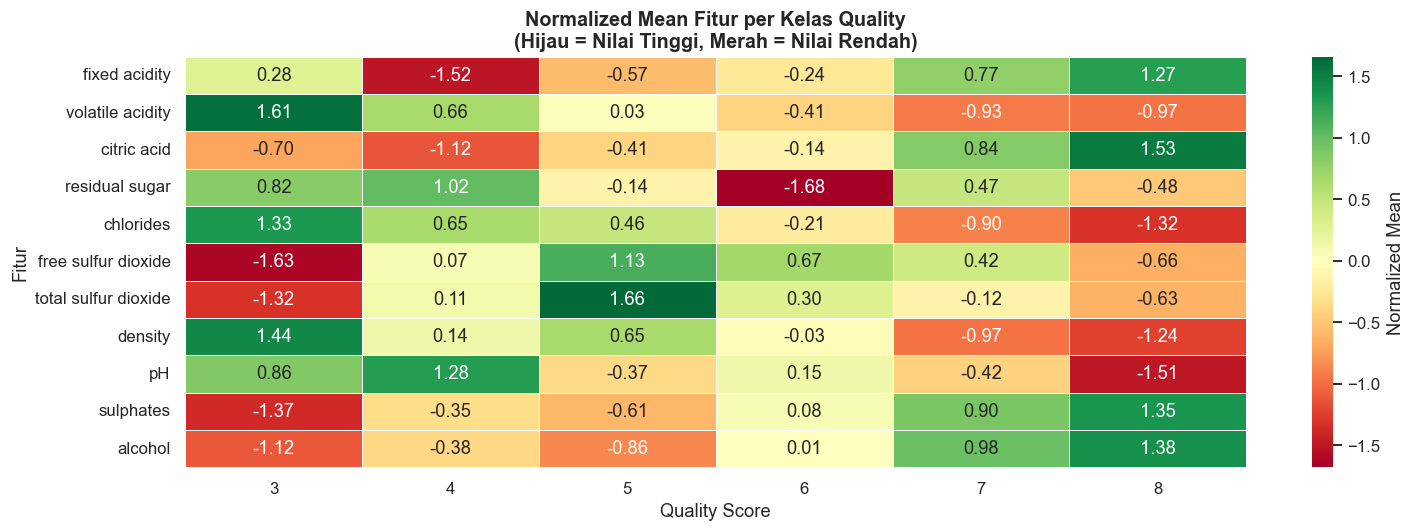

💡 Baca baris per baris: fitur mana yang naik/turun seiring quality meningkat


In [13]:
# ── Mean fitur per kelas quality (heatmap) ───────────────────────────────
mean_by_quality = train_df.groupby('quality')[feature_cols].mean()
mean_norm = (mean_by_quality - mean_by_quality.mean()) / mean_by_quality.std()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    mean_norm.T, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.4, ax=ax, cbar_kws={'label': 'Normalized Mean'}
)
ax.set_title('Normalized Mean Fitur per Kelas Quality\n(Hijau = Nilai Tinggi, Merah = Nilai Rendah)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Fitur')
plt.tight_layout()
plt.show()
print('💡 Baca baris per baris: fitur mana yang naik/turun seiring quality meningkat')


> **📌 Penjelasan Output:**  
>Visualisasi Heatmap Normalized Mean tersebut memberikan gambaran komprehensif mengenai profil kimiawi rata-rata untuk setiap tingkatan skor kualitas wine setelah datanya distandarisasi menggunakan skala Z-score. Dengan menggunakan gradasi warna dari merah (nilai jauh di bawah rata-rata) hingga hijau (nilai jauh di atas rata-rata), kita dapat dengan mudah mendeteksi "sidik jari" kimiawi yang membedakan setiap kelas. Terlihat sangat jelas bahwa wine berkualitas tinggi (skor 7-8) secara konsisten ditandai dengan warna hijau pekat pada fitur alcohol, citric acid, dan sulphates, yang berarti komponen-komponen ini memiliki nilai rata-rata yang jauh lebih tinggi pada wine terbaik. Sebaliknya, wine berkualitas rendah (skor 3-4) justru didominasi oleh warna hijau pada fitur volatile acidity, chlorides, dan density, yang mengonfirmasi bahwa tingginya kadar asam volatil dan kepekatan cairan merupakan indikator utama penurunan kualitas.

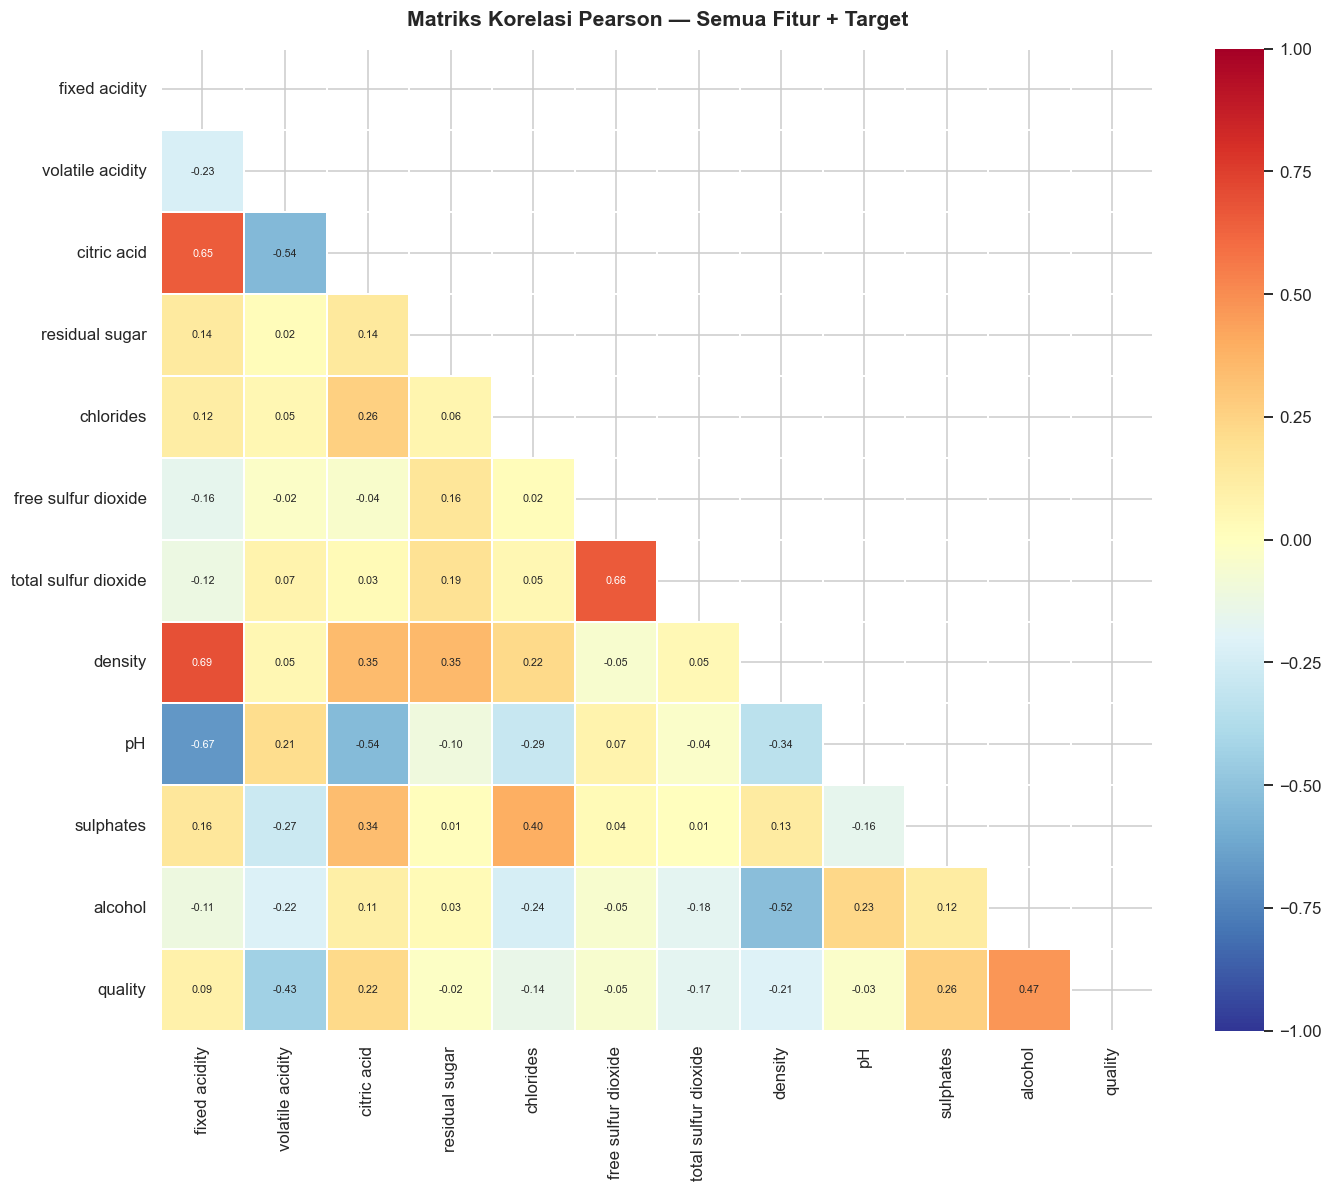

In [14]:
# ── Heatmap Korelasi Pearson ──────────────────────────────────────────────
corr_matrix = train_df[feature_cols + ['quality']].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
hm = sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, linewidths=0.3,
    vmin=-1, vmax=1, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Matriks Korelasi Pearson — Semua Fitur + Target',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Matriks Korelasi Pearson tersebut memetakan hubungan linear antar variabel dalam dataset kualitas wine, di mana nilai koefisiennya menunjukkan kekuatan serta arah hubungan antar fitur dalam rentang $-1$ hingga $1$. Dari perspektif target quality, fitur alcohol menunjukkan korelasi positif terkuat (0.47) yang menandakan bahwa kadar alkohol yang lebih tinggi cenderung berasosiasi dengan penilaian kualitas yang lebih baik, sementara volatile acidity memiliki korelasi negatif yang signifikan (-0.43) karena kadar asam volatil yang tinggi secara kimiawi sering dikaitkan dengan aroma tajam seperti cuka yang merusak rasa. Selain itu, matriks ini mengungkap hubungan teknis antar variabel seperti korelasi negatif kuat antara fixed acidity dan pH (-0.67) yang selaras dengan hukum dasar kimia, serta korelasi positif antara fixed acidity dan density (0.69) yang mencerminkan kontribusi asam terhadap massa jenis cairan. 

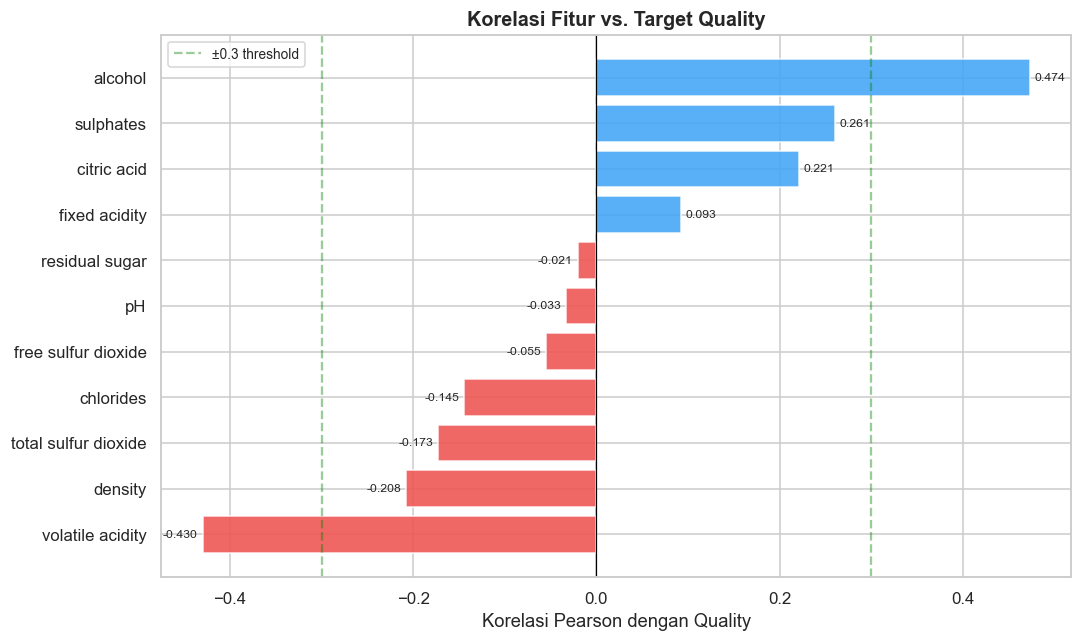


=== Fitur dengan Korelasi Tertinggi dengan Quality ===
  alcohol                         0.4736  (↑ Positif)
  volatile acidity               -0.4301  (↓ Negatif)
  sulphates                       0.2607  (↑ Positif)
  citric acid                     0.2213  (↑ Positif)
  density                        -0.2079  (↓ Negatif)


In [15]:
# ── Korelasi fitur dengan target (bar chart) ─────────────────────────────
corr_target = corr_matrix['quality'].drop('quality').sort_values()

colors_c = ['#EF5350' if v < 0 else '#42A5F5' for v in corr_target.values]
fig, ax  = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_target.index, corr_target.values,
               color=colors_c, edgecolor='white', alpha=0.88)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='green',  linestyle='--', alpha=0.4, label='±0.3 threshold')
ax.axvline(-0.3, color='green',  linestyle='--', alpha=0.4)
ax.set_xlabel('Korelasi Pearson dengan Quality')
ax.set_title('Korelasi Fitur vs. Target Quality', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== Fitur dengan Korelasi Tertinggi dengan Quality ===')
strong = corr_target[corr_target.abs() > 0.2].sort_values(key=abs, ascending=False)
for feat, val in strong.items():
    arah = '↑ Positif' if val > 0 else '↓ Negatif'
    print(f'  {feat:<30} {val:>7.4f}  ({arah})')


> **📌 Penjelasan Output:**  
>visualisasi korelasi fitur terhadap target Quality ini memberikan gambaran hierarkis mengenai variabel mana yang paling berpengaruh secara linear terhadap penilaian kualitas wine. Berdasarkan grafik tersebut, alcohol muncul sebagai prediktor positif terkuat dengan nilai korelasi 0.474, yang mengindikasikan bahwa kenaikan kadar alkohol secara umum berkaitan dengan peningkatan kualitas dalam dataset ini. Sebaliknya, volatile acidity menjadi faktor penghambat paling signifikan dengan korelasi negatif sebesar -0.430, yang mencerminkan secara teknis bahwa kadar asam yang mudah menguap cenderung menurunkan skor kualitas karena memberikan aroma yang tidak diinginkan.

---
## 🛠️ Langkah 3 — Data Preprocessing

Mencakup: **Duplikat** → **Missing Values** → **Outlier (IQR Capping)** → **Feature Engineering**



In [19]:
# ── 3A: Inisialisasi salinan bersih ──────────────────────────────────────
train_clean = train_df.copy()
test_clean  = test_df.copy()
print(f'Training : {train_clean.shape}')
print(f'Testing  : {test_clean.shape}')


Training : (857, 13)
Testing  : (286, 12)


### 3A — Penanganan Duplikat

In [20]:
# ── Cek dan hapus duplikat ────────────────────────────────────────────────
n_dup_train = train_clean.duplicated(subset=feature_cols).sum()
n_dup_test  = test_clean.duplicated(subset=feature_cols).sum()

print(f'Duplikat training : {n_dup_train} ({n_dup_train/len(train_clean)*100:.2f}%)')
print(f'Duplikat testing  : {n_dup_test} ({n_dup_test/len(test_clean)*100:.2f}%)')

if n_dup_train > 0:
    train_clean = train_clean.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)
    print(f'→ Training setelah drop duplikat: {len(train_clean)} baris')
else:
    print('✅ Tidak ada duplikat di training.')

if n_dup_test > 0:
    test_clean = test_clean.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)
    print(f'→ Testing setelah drop duplikat: {len(test_clean)} baris')
else:
    print('✅ Tidak ada duplikat di testing.')


Duplikat training : 76 (8.87%)
Duplikat testing  : 4 (1.40%)
→ Training setelah drop duplikat: 781 baris
→ Testing setelah drop duplikat: 282 baris


> **📌 Penjelasan Output:**  
> dari output Tercatat sebanyak 76 sampel duplikat (8.87%) pada dataset pelatihan dan 4 sampel duplikat (1.40%) pada dataset pengujian yang telah berhasil diidentifikasi dan dieliminasi. Setelah proses pembersihan, jumlah data yang tersisa menjadi 781 baris untuk pelatihan dan 282 baris untuk pengujian.

### 3B — Penanganan Missing Values

In [21]:
# ── Visualisasi missing values ───────────────────────────────────────────
mv_train = train_clean.isnull().sum()
mv_test  = test_clean.isnull().sum()

total_mv_train = mv_train.sum()
total_mv_test  = mv_test.sum()

if total_mv_train > 0 or total_mv_test > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    mv_pct_train = (mv_train / len(train_clean) * 100)
    mv_pct_test  = (mv_test  / len(test_clean)  * 100)
    
    axes[0].barh(mv_pct_train[mv_pct_train > 0].index,
                 mv_pct_train[mv_pct_train > 0].values, color='#EF9A9A')
    axes[0].set_title('Missing Values — Training (%)')
    axes[0].set_xlabel('% Missing')
    
    axes[1].barh(mv_pct_test[mv_pct_test > 0].index,
                 mv_pct_test[mv_pct_test > 0].values, color='#90CAF9')
    axes[1].set_title('Missing Values — Testing (%)')
    axes[1].set_xlabel('% Missing')
    
    plt.suptitle('Visualisasi Missing Values', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada missing values — dataset bersih.')

print(f'\nTotal MV Training: {total_mv_train}')
print(f'Total MV Testing : {total_mv_test}')


✅ Tidak ada missing values — dataset bersih.

Total MV Training: 0
Total MV Testing : 0


> **📌 Penjelasan Output:**  
>Karena Total Misiing value Training: 0 dan Total MV Testing: 0, maka tidak perlu penanganan missing value

In [22]:
# ── Imputasi Median (antisipasi future data dengan MV) ───────────────────
for col in feature_cols:
    if train_clean[col].isnull().any():
        median_val = train_clean[col].median()
        train_clean[col] = train_clean[col].fillna(median_val)
        print(f'  [Train] Imputed [{col}] dengan median = {median_val:.4f}')
    if test_clean[col].isnull().any():
        median_val = train_clean[col].median()  # pakai median TRAINING (no leakage)
        test_clean[col] = test_clean[col].fillna(median_val)
        print(f'  [Test]  Imputed [{col}] dengan median training = {median_val:.4f}')

print('\n✅ Penanganan missing values selesai.')



✅ Penanganan missing values selesai.


### 3C — Deteksi & Penanganan Outlier (IQR Capping)

In [23]:
# ── Fungsi deteksi outlier ────────────────────────────────────────────────
def detect_outliers_iqr(df, cols, factor=1.5):
    result = {}
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - factor * IQR
        hi  = Q3 + factor * IQR
        mask    = (df[col] < lo) | (df[col] > hi)
        n_out   = int(mask.sum())
        result[col] = {
            'Q1': round(Q1, 4), 'Q3': round(Q3, 4), 'IQR': round(IQR, 4),
            'Lower': round(lo, 4), 'Upper': round(hi, 4),
            'Outliers': n_out,
            'Outliers (%)': round(n_out / len(df) * 100, 2)
        }
    return pd.DataFrame(result).T

outlier_df = detect_outliers_iqr(train_clean, feature_cols)
print('=== Laporan Deteksi Outlier (IQR, factor=1.5) ===')
print(outlier_df[['Lower', 'Upper', 'Outliers', 'Outliers (%)']].sort_values('Outliers', ascending=False))
print(f'\nTotal fitur dengan outlier: {(outlier_df["Outliers"] > 0).sum()}')


=== Laporan Deteksi Outlier (IQR, factor=1.5) ===
                        Lower    Upper  Outliers  Outliers (%)
residual sugar         0.8500   3.6500   71.0000        9.0900
chlorides              0.0375   0.1215   47.0000        6.0200
fixed acidity          4.2500  11.8500   35.0000        4.4800
sulphates              0.2950   0.9750   30.0000        3.8400
density                0.9921   1.0012   23.0000        2.9400
total sulfur dioxide -42.0000 126.0000   18.0000        2.3000
free sulfur dioxide  -14.0000  42.0000   14.0000        1.7900
pH                     2.9250   3.6850   13.0000        1.6600
volatile acidity       0.0400   1.0000    9.0000        1.1500
alcohol                6.9500  13.7500    4.0000        0.5100
citric acid           -0.4050   0.9150    1.0000        0.1300

Total fitur dengan outlier: 11


> **📌 Penjelasan Output:**  
>hasil Deteksi Outlier menggunakan metode Interquartile Range (IQR) dengan faktor 1.5, sebuah standar statistik untuk menentukan batas wajar data di mana nilai di luar rentang $[Q1 - 1.5 \times IQR]$ hingga $[Q3 + 1.5 \times IQR]$ dikategorikan sebagai pencilan. Berdasarkan tabel tersebut, ditemukan bahwa seluruh 11 fitur dalam dataset memiliki outlier, dengan residual sugar muncul sebagai fitur yang paling "berisik" karena menyimpan 71 pencilan atau sekitar 9.09% dari total data, disusul oleh chlorides sebesar 6.02%

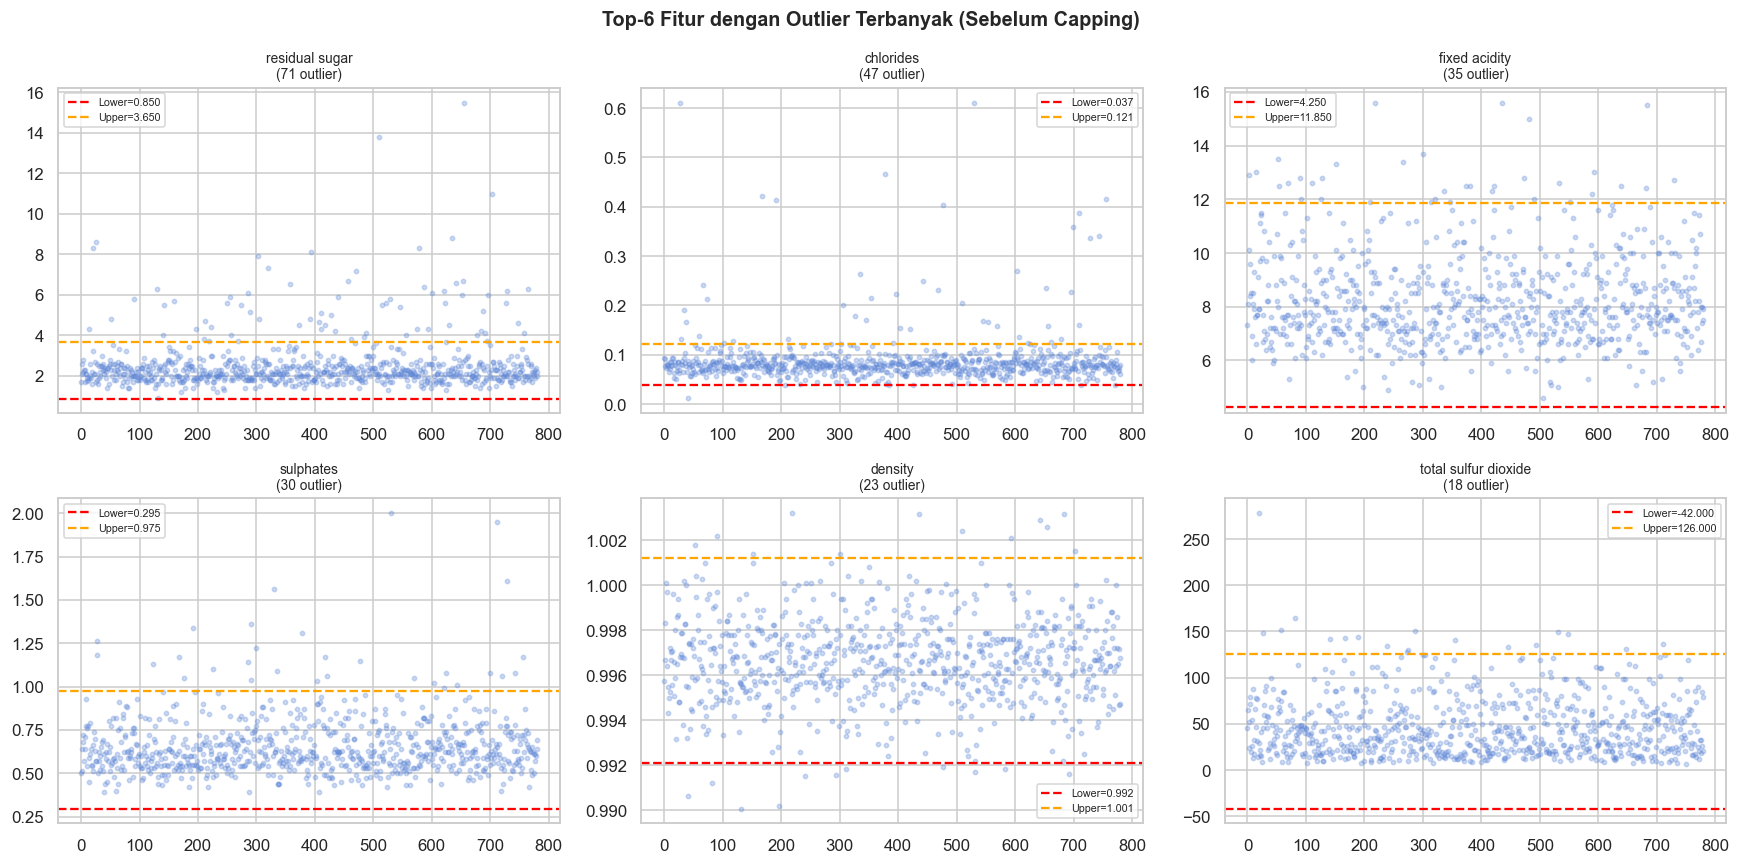

In [24]:
# ── Visualisasi outlier sebelum capping ──────────────────────────────────
top_outlier_feats = outlier_df.sort_values('Outliers', ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_feats):
    ax = axes[i]
    ax.scatter(range(len(train_clean)), train_clean[col], alpha=0.3, s=8, color='#5C85D6')
    lo = outlier_df.loc[col, 'Lower']
    hi = outlier_df.loc[col, 'Upper']
    ax.axhline(lo, color='red',    linewidth=1.5, linestyle='--', label=f'Lower={lo:.3f}')
    ax.axhline(hi, color='orange', linewidth=1.5, linestyle='--', label=f'Upper={hi:.3f}')
    ax.set_title(f'{col}\n({int(outlier_df.loc[col, "Outliers"])} outlier)', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Top-6 Fitur dengan Outlier Terbanyak (Sebelum Capping)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi tersebut menyajikan scatter plots untuk enam fitur dengan jumlah pencilan terbanyak, yang bertujuan untuk memetakan distribusi data terhadap batas ambang statistik sebelum dilakukan tindakan perbaikan. Garis putus-putus merah (Lower) dan oranye (Upper) pada setiap grafik merepresentasikan batas bawah dan batas atas yang dihitung menggunakan metode $1.5 \times \text{IQR}$, di mana setiap titik yang berada di luar koridor tersebut secara resmi dianggap sebagai outlier. 

In [25]:
# ── Capping outlier ───────────────────────────────────────────────────────
def cap_outliers_iqr(df_train, df_test, cols, factor=1.5):
    df_tr = df_train.copy()
    df_te = df_test.copy()
    summary = []
    for col in cols:
        Q1  = df_train[col].quantile(0.25)
        Q3  = df_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - factor * IQR
        hi  = Q3 + factor * IQR
        n_before_tr = int(((df_train[col] < lo) | (df_train[col] > hi)).sum())
        n_before_te = int(((df_test[col]  < lo) | (df_test[col]  > hi)).sum())
        df_tr[col] = df_tr[col].clip(lo, hi)
        df_te[col] = df_te[col].clip(lo, hi)
        if n_before_tr > 0:
            summary.append({'Fitur': col, 'Lower': round(lo,4), 'Upper': round(hi,4),
                            'Train Capped': n_before_tr, 'Test Capped': n_before_te})
            print(f'  [{col:<26}] lo={lo:>9.4f}  hi={hi:>9.4f} | train={n_before_tr}  test={n_before_te}')
    return df_tr, df_te, pd.DataFrame(summary)

print('=== Proses IQR Capping ===')
train_clean, test_clean, cap_summary = cap_outliers_iqr(train_clean, test_clean, feature_cols)

# Verifikasi setelah capping
outlier_after = detect_outliers_iqr(train_clean, feature_cols)
total_remain  = int(outlier_after['Outliers'].sum())
print(f'\n✅ Total outlier SETELAH capping: {total_remain}')


=== Proses IQR Capping ===
  [fixed acidity             ] lo=   4.2500  hi=  11.8500 | train=35  test=19
  [volatile acidity          ] lo=   0.0400  hi=   1.0000 | train=9  test=6
  [citric acid               ] lo=  -0.4050  hi=   0.9150 | train=1  test=0
  [residual sugar            ] lo=   0.8500  hi=   3.6500 | train=71  test=34
  [chlorides                 ] lo=   0.0375  hi=   0.1215 | train=47  test=17
  [free sulfur dioxide       ] lo= -14.0000  hi=  42.0000 | train=14  test=3
  [total sulfur dioxide      ] lo= -42.0000  hi= 126.0000 | train=18  test=14
  [density                   ] lo=   0.9921  hi=   1.0012 | train=23  test=11
  [pH                        ] lo=   2.9250  hi=   3.6850 | train=13  test=12
  [sulphates                 ] lo=   0.2950  hi=   0.9750 | train=30  test=13
  [alcohol                   ] lo=   6.9500  hi=  13.7500 | train=4  test=3

✅ Total outlier SETELAH capping: 0


> **📌 Penjelasan Output:**  
>Output tersebut merangkum keberhasilan proses IQR Capping (juga dikenal sebagai Winsorization) yang dilakukan untuk menangani pencilan pada seluruh fitur dataset tanpa harus menghapus baris data. Melalui metode ini, setiap nilai yang berada di luar batas bawah (lo) dan batas atas (hi) "dipangkas" atau disesuaikan nilainya agar setara dengan ambang batas tersebut; misalnya, pada fitur residual sugar, nilai yang lebih besar dari 3.6500 secara otomatis diubah menjadi tepat 3.6500.  Berdasarkan rincian tersebut, fitur residual sugar adalah yang paling banyak mengalami penyesuaian dengan total 71 sampel pada data pelatihan dan 34 sampel pada data pengujian

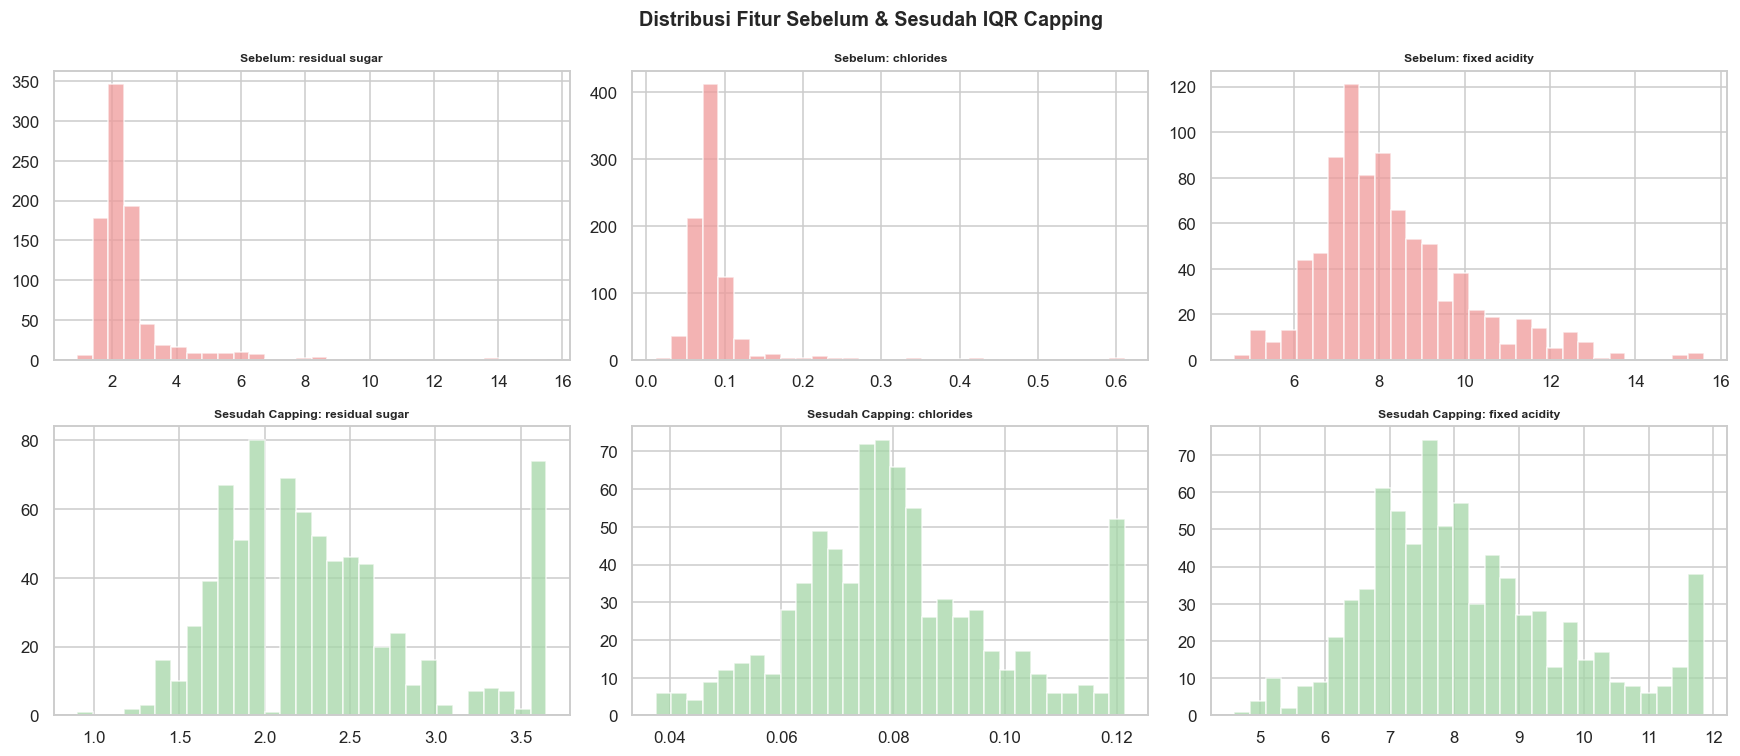

In [26]:
# ── Visualisasi sebelum vs sesudah capping ───────────────────────────────
if len(top_outlier_feats) > 0:
    fig, axes = plt.subplots(2, min(3, len(top_outlier_feats)), figsize=(16, 7))
    if len(top_outlier_feats) == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    
    col_sample = top_outlier_feats[:min(3, len(top_outlier_feats))]
    for i, col in enumerate(col_sample):
        # Sebelum (pakai train_df asli)
        axes[0][i].hist(train_df[col], bins=30, color='#EF9A9A', alpha=0.75, edgecolor='white')
        axes[0][i].set_title(f'Sebelum: {col}', fontsize=8, fontweight='bold')
        
        # Sesudah capping
        axes[1][i].hist(train_clean[col], bins=30, color='#A5D6A7', alpha=0.75, edgecolor='white')
        axes[1][i].set_title(f'Sesudah Capping: {col}', fontsize=8, fontweight='bold')

    plt.suptitle('Distribusi Fitur Sebelum & Sesudah IQR Capping',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi tersebut memberikan perbandingan grafis yang sangat jelas mengenai dampak transformasi IQR Capping terhadap distribusi fitur residual sugar, chlorides, dan fixed acidity. Pada baris atas (warna merah), terlihat distribusi asli yang memiliki "ekor" sangat panjang ke arah kanan, di mana titik-titik data ekstrem seperti pada residual sugar yang mencapai angka 16 bertindak sebagai pencilan yang mendistorsi skala sumbu-$x$. Setelah dilakukan capping pada baris bawah (warna hijau), rentang data menjadi lebih terkonsentrasi karena nilai-nilai ekstrem tersebut telah dipangkas dan disesuaikan ke batas atas statistik, yaitu $Q3 + 1.5 \times IQR$. Munculnya lonjakan atau spike di ujung paling kanan pada setiap grafik hijau adalah bukti visual bahwa seluruh outliers yang sebelumnya tersebar jauh kini telah "dikumpulkan" tepat pada garis batas maksimal, sehingga menciptakan distribusi yang lebih stabil dan mencegah model machine learning memberikan bobot yang berlebihan pada nilai-nilai anomali tersebut.

### 3D — Feature Engineering

In [27]:
# ── Buat fitur baru berbasis domain enologi ───────────────────────────────
def engineer_features(df):
    """Membuat fitur baru berbasis pengetahuan domain enologi (wine chemistry)."""
    df = df.copy()
    # Rasio sulfur dioksida
    df['free_to_total_so2']     = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
    # Total keasaman
    df['total_acidity']         = df['fixed acidity'] + df['volatile acidity']
    # Rasio antar komponen
    df['volatile_fixed_ratio']  = df['volatile acidity'] / (df['fixed acidity'] + 1e-6)
    df['alcohol_acidity_ratio'] = df['alcohol'] / (df['volatile acidity'] + 1e-6)
    df['sugar_alcohol_ratio']   = df['residual sugar'] / (df['alcohol'] + 1e-6)
    # Interaksi
    df['sulphates_alcohol']     = df['sulphates'] * df['alcohol']
    df['density_alcohol_ratio'] = df['density'] / (df['alcohol'] + 1e-6)
    df['acidity_pH_ratio']      = df['fixed acidity'] / (df['pH'] + 1e-6)
    # Tambahan: total mineral
    df['chlorides_sulphates']   = df['chlorides'] * df['sulphates']
    df['so2_per_sugar']         = df['total sulfur dioxide'] / (df['residual sugar'] + 1e-6)
    return df

train_clean = engineer_features(train_clean)
test_clean  = engineer_features(test_clean)

new_feats    = ['free_to_total_so2', 'total_acidity', 'volatile_fixed_ratio',
                'alcohol_acidity_ratio', 'sugar_alcohol_ratio', 'sulphates_alcohol',
                'density_alcohol_ratio', 'acidity_pH_ratio',
                'chlorides_sulphates', 'so2_per_sugar']
all_features = [c for c in train_clean.columns if c not in ['quality', 'Id']]

print(f'Fitur asli         : {len(feature_cols)}')
print(f'Fitur rekayasa baru: {len(new_feats)}')
print(f'Total fitur        : {len(all_features)}')
print(f'\nFitur baru: {new_feats}')


Fitur asli         : 11
Fitur rekayasa baru: 10
Total fitur        : 21

Fitur baru: ['free_to_total_so2', 'total_acidity', 'volatile_fixed_ratio', 'alcohol_acidity_ratio', 'sugar_alcohol_ratio', 'sulphates_alcohol', 'density_alcohol_ratio', 'acidity_pH_ratio', 'chlorides_sulphates', 'so2_per_sugar']


> **📌 Penjelasan Output:**  
>Tahap Feature Engineering yang dilakukan melalui fungsi engineer_features ini merupakan langkah strategis untuk memperkaya dataset dengan menciptakan variabel baru yang didasarkan pada pengetahuan domain enologi (ilmu kimia wine). Syntax tersebut meracik 10 fitur tambahan melalui operasi rasio dan interaksi, seperti penggabungan tingkat keasaman dalam total_acidity atau perbandingan gula terhadap alkohol, serta menyisipkan konstanta $1 \times 10^{-6}$ sebagai pengaman untuk mencegah kesalahan pembagian dengan nol (division by zero). Berdasarkan outputnya, dimensi dataset kamu kini meningkat signifikan, melonjak dari 11 fitur asli menjadi 21 fitur total. Penambahan fitur rekayasa ini sangat krusial karena memberikan perspektif hubungan antar variabel yang lebih kompleks bagi model machine learning, sehingga memungkinkannya menangkap sinyal kualitas yang lebih halus yang mungkin tidak terdeteksi jika hanya mengandalkan variabel mentah secara terpisah.

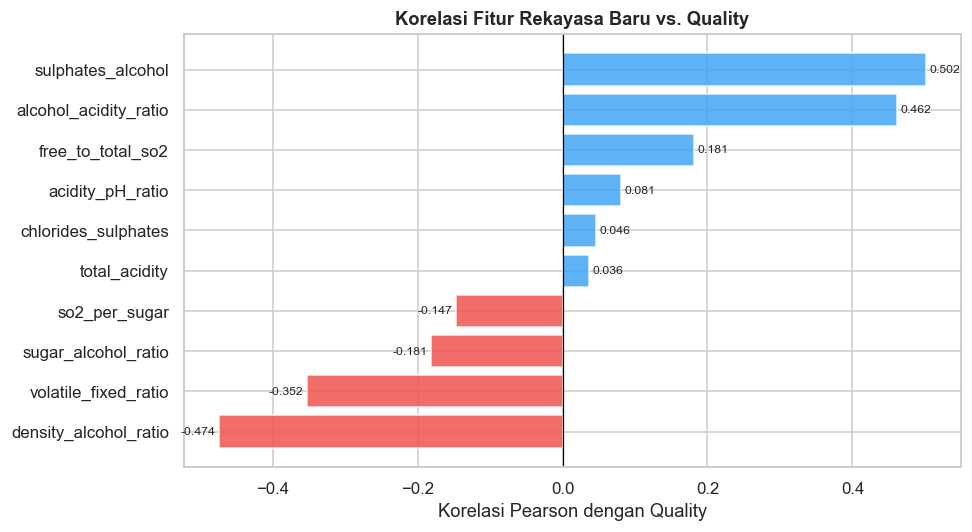


✅ Feature engineering selesai.
Shape training akhir: (781, 23)
Shape testing  akhir: (282, 22)


In [28]:
# ── Korelasi fitur baru dengan target ────────────────────────────────────
corr_new = train_clean[new_feats + ['quality']].corr()['quality'].drop('quality').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_n = ['#EF5350' if v < 0 else '#42A5F5' for v in corr_new.values]
ax.barh(corr_new.index, corr_new.values, color=colors_n, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Korelasi Pearson dengan Quality')
ax.set_title('Korelasi Fitur Rekayasa Baru vs. Quality', fontsize=12, fontweight='bold')
for i, (feat, val) in enumerate(corr_new.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

print('\n✅ Feature engineering selesai.')
print(f'Shape training akhir: {train_clean.shape}')
print(f'Shape testing  akhir: {test_clean.shape}')


> **📌 Penjelasan Output:**  
>Visualisasi Korelasi Fitur Rekayasa Baru vs. Quality ini membuktikan efektivitas dari tahap feature engineering yang kamu lakukan, di mana beberapa fitur buatan justru menunjukkan hubungan yang lebih kuat dengan target dibandingkan fitur aslinya. Fitur sulphates_alcohol muncul sebagai prediktor positif paling dominan dengan nilai korelasi 0.502, melampaui korelasi fitur alkohol tunggal (0.47), yang menandakan bahwa interaksi antara kadar sulfat dan alkohol memberikan sinyal kualitas yang lebih tajam bagi model. Di sisi lain, fitur density_alcohol_ratio menunjukkan korelasi negatif yang sangat signifikan sebesar -0.474, menegaskan bahwa perbandingan antara massa jenis dan alkohol merupakan indikator krusial dalam menentukan klasifikasi wine.

Keberhasilan fitur rekayasa seperti alcohol_acidity_ratio (0.462) dan volatile_fixed_ratio (-0.352) dalam menembus angka korelasi di atas ambang batas 0.3 menunjukkan bahwa transformasi berbasis domain enologi ini berhasil mengekstraksi informasi tersembunyi dari data mentah. Dengan adanya fitur-fitur baru yang memiliki korelasi tinggi ini, model machine learning kamu akan memiliki landasan matematis yang lebih kuat untuk membedakan kelas kualitas, karena fitur-fitur tersebut secara efektif merangkum hubungan kompleks antar komponen kimia wine ke dalam satu variabel prediktif.

---
## ⚠️ Langkah 4 — Analisis Imbalanced Target

> Kelas yang tidak seimbang menyebabkan model **bias ke kelas mayoritas** → perlu strategi penyeimbangan.


In [29]:
# ── Pisahkan fitur & target ───────────────────────────────────────────────
X            = train_clean[all_features]
y            = train_clean['quality'].values
X_test_final = test_clean[all_features]
test_ids     = test_clean['Id']

quality_counts = pd.Series(y).value_counts().sort_index()
pct            = (quality_counts / quality_counts.sum() * 100).round(2)

print(f'Shape X_train : {X.shape}')
print(f'Shape X_test  : {X_test_final.shape}')
print(f'Kelas target  : {sorted(np.unique(y))}')


Shape X_train : (781, 21)
Shape X_test  : (282, 21)
Kelas target  : [3, 4, 5, 6, 7, 8]


> **📌 Penjelasan Output:**  
>swlanjutnya tahap  memisahkan variabel independen (fitur) dan variabel dependen (target) serta melakukan inspeksi terhadap dimensi data setelah seluruh proses pembersihan selesai. Output menunjukkan bahwa dataset kini memiliki 21 fitur, yang mengonfirmasi keberhasilan tahap feature engineering sebelumnya, dengan total sampel sebanyak 781 baris untuk pelatihan dan 282 baris untuk pengujian.Fokus utama pada langkah ini adalah persiapan untuk menangani Imbalanced Target pada kolom quality yang memiliki rentang kelas unik dari 3 hingga 8. Identifikasi sebaran kelas ini sangat penting karena distribusi yang tidak merata dapat menyebabkan model mengalami bias ke kelas mayoritas (seperti skor 5 dan 6) dan mengabaikan pola pada kelas minoritas (seperti skor 3 dan 8). Dengan struktur data $X$ dan $y$ yang sudah terpisah,

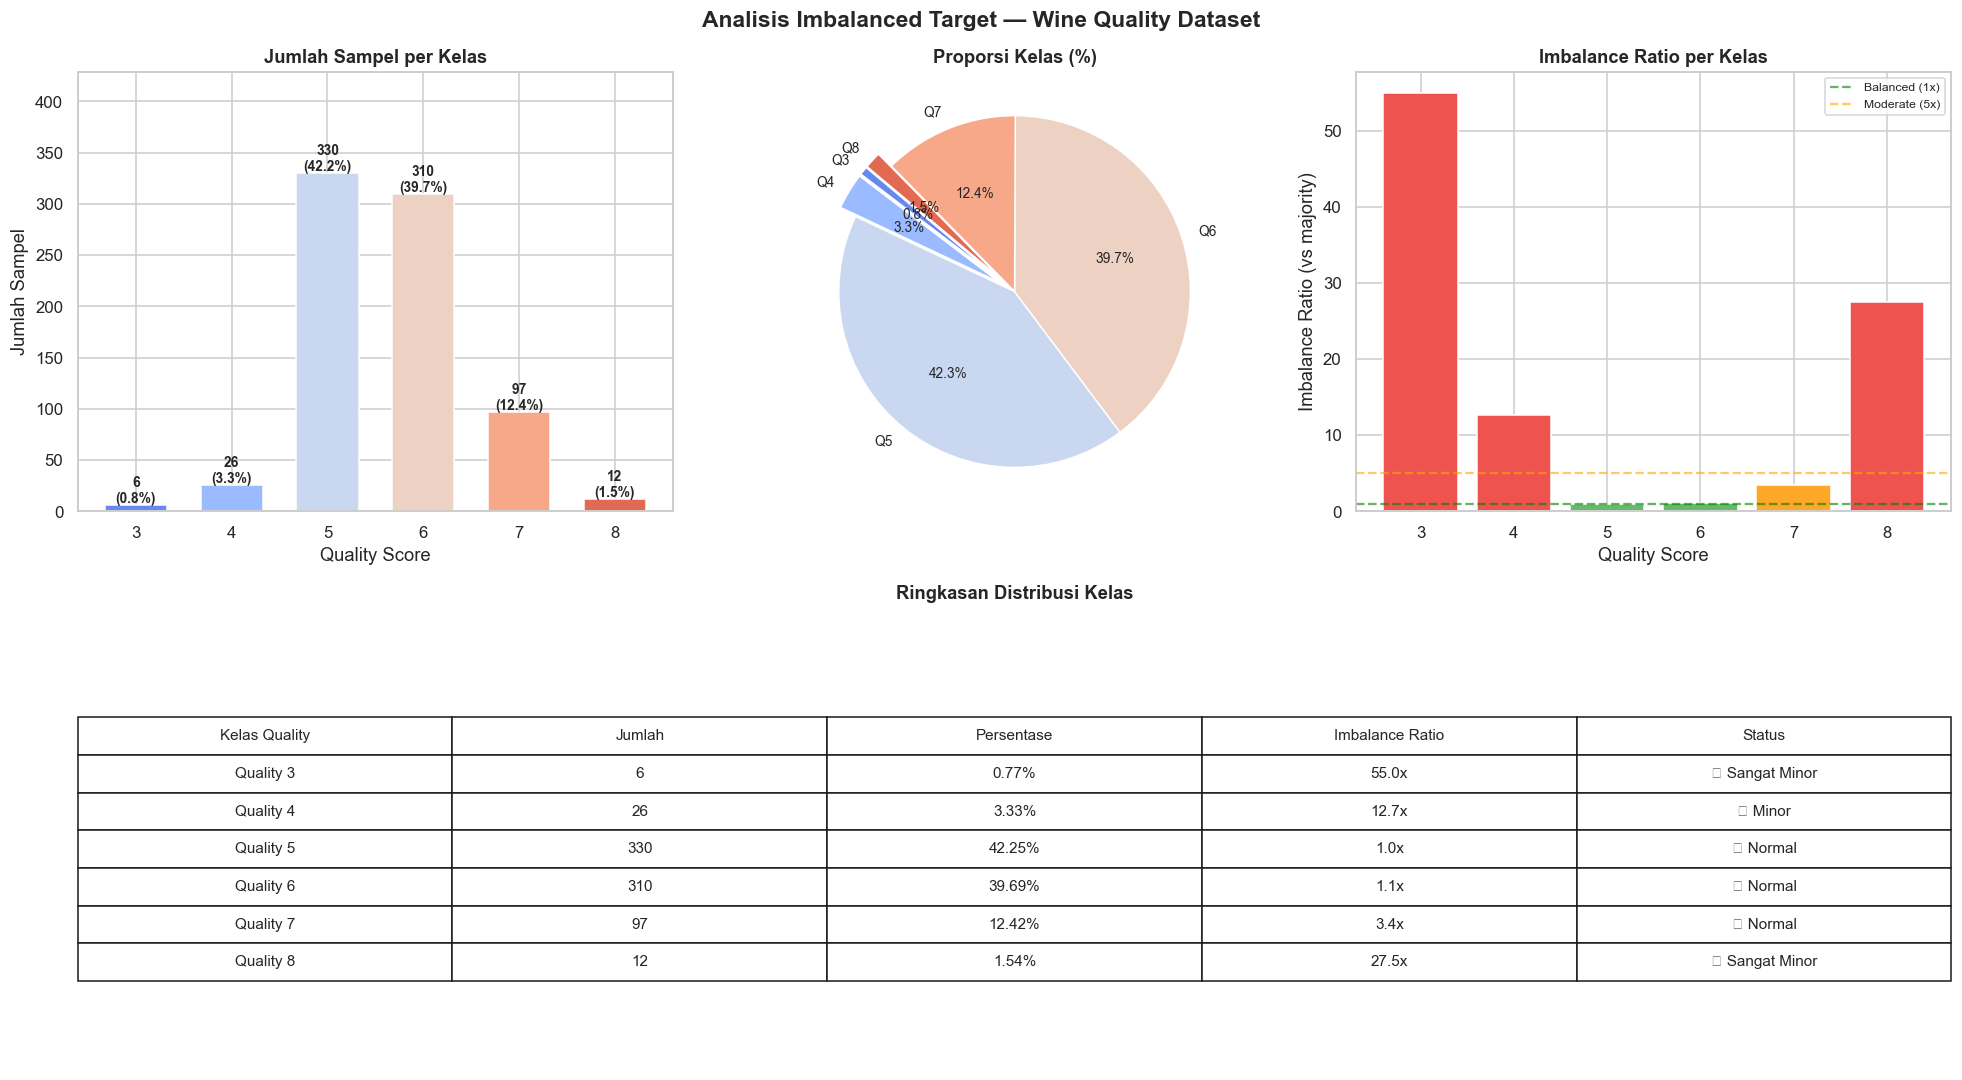


Kelas Mayoritas  : Quality 5 (330 sampel)
Kelas Minoritas  : Quality 3 (6 sampel)
Imbalance Ratio  : 55.0x
⚠️  Imbalance BERAT → SMOTE sangat direkomendasikan!


In [30]:
# ── Visualisasi distribusi kelas (4 panel) ───────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

palette = sns.color_palette('coolwarm', len(quality_counts))

# Panel 1: Bar chart jumlah
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(quality_counts.index.astype(str), quality_counts.values,
               color=palette, edgecolor='white', width=0.65)
ax1.set_xlabel('Quality Score')
ax1.set_ylabel('Jumlah Sampel')
ax1.set_title('Jumlah Sampel per Kelas', fontweight='bold')
for bar, (q, v) in zip(bars, quality_counts.items()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{v}\n({pct[q]:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax1.set_ylim(0, quality_counts.max() * 1.3)

# Panel 2: Pie chart
ax2 = fig.add_subplot(gs[0, 1])
explode = [0.1 if p < 5 else 0 for p in pct.values]
ax2.pie(quality_counts.values, labels=[f'Q{k}' for k in quality_counts.index],
        autopct='%1.1f%%', startangle=140, colors=palette, explode=explode,
        textprops={'fontsize': 9})
ax2.set_title('Proporsi Kelas (%)', fontweight='bold')

# Panel 3: Imbalance Ratio per kelas
ax3 = fig.add_subplot(gs[0, 2])
majority_count = quality_counts.max()
ratios = majority_count / quality_counts
color_ratio = ['#EF5350' if r > 5 else ('#FFA726' if r > 2 else '#66BB6A') for r in ratios.values]
ax3.bar(ratios.index.astype(str), ratios.values, color=color_ratio, edgecolor='white')
ax3.axhline(1, color='green',  linestyle='--', alpha=0.6, label='Balanced (1x)')
ax3.axhline(5, color='orange', linestyle='--', alpha=0.6, label='Moderate (5x)')
ax3.set_xlabel('Quality Score')
ax3.set_ylabel('Imbalance Ratio (vs majority)')
ax3.set_title('Imbalance Ratio per Kelas', fontweight='bold')
ax3.legend(fontsize=8)

# Panel 4: Tabel ringkasan
ax4 = fig.add_subplot(gs[1, :])
ax4.axis('off')
table_data = [
    [f'Quality {q}', v, f'{p:.2f}%', f'{majority_count/v:.1f}x',
     '🔴 Sangat Minor' if p < 2 else ('🟡 Minor' if p < 10 else '🟢 Normal')]
    for q, v, p in zip(quality_counts.index, quality_counts.values, pct.values)
]
table = ax4.table(
    cellText=table_data,
    colLabels=['Kelas Quality', 'Jumlah', 'Persentase', 'Imbalance Ratio', 'Status'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
ax4.set_title('Ringkasan Distribusi Kelas', fontweight='bold', pad=20)

plt.suptitle('Analisis Imbalanced Target — Wine Quality Dataset',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Ringkasan statistik
majority_count = quality_counts.max()
minority_count = quality_counts.min()
ir = majority_count / minority_count
print(f'\nKelas Mayoritas  : Quality {quality_counts.idxmax()} ({majority_count} sampel)')
print(f'Kelas Minoritas  : Quality {quality_counts.idxmin()} ({minority_count} sampel)')
print(f'Imbalance Ratio  : {ir:.1f}x')
if ir > 5:
    print('⚠️  Imbalance BERAT → SMOTE sangat direkomendasikan!')
elif ir > 2:
    print('⚠️  Imbalance SEDANG → SMOTE atau class_weight="balanced" direkomendasikan.')
else:
    print('✅ Distribusi relatif seimbang.')


> **📌 Penjelasan Output:**  
>Output visualisasi Analisis Imbalanced Target tersebut mengungkap tantangan besar dalam dataset kamu, yaitu ketidakseimbangan kelas yang sangat signifikan. Melalui grafik "Jumlah Sampel per Kelas" dan "Proporsi Kelas", terlihat bahwa kategori kualitas 5 dan 6 mendominasi panggung dengan total akumulasi lebih dari 80% data, sedangkan kelas ekstrem seperti skor 3 dan 8 terkubur sebagai kategori Sangat Minor dengan persentase di bawah 2%.  Hal yang paling mencolok adalah kolom Imbalance Ratio, di mana kelas 3 memiliki rasio 55.0x terhadap kelas mayoritas; artinya, untuk setiap satu sampel wine kualitas 3, terdapat 55 sampel wine kualitas 5.

---
## 🔄 Langkah 5 — SMOTE (Synthetic Minority Over-sampling Technique)

**Cara kerja SMOTE:**
- Untuk setiap sampel minoritas, cari K-nearest neighbors
- Buat sampel sintetis baru di antara sampel asli dan tetangganya
- Lebih baik dari random oversampling karena menghasilkan sampel yang **realistis**




In [31]:
# ── Label Encoding ───────────────────────────────────────────────────────
# XGBoost & LightGBM memerlukan label integer 0-based
le          = LabelEncoder()
y_enc       = le.fit_transform(y)

print('=== Label Encoding ===')
for orig, enc in zip(le.classes_, range(len(le.classes_))):
    count = int((y == orig).sum())
    print(f'  Quality {orig} → Label {enc}  ({count} sampel)')


=== Label Encoding ===
  Quality 3 → Label 0  (6 sampel)
  Quality 4 → Label 1  (26 sampel)
  Quality 5 → Label 2  (330 sampel)
  Quality 6 → Label 3  (310 sampel)
  Quality 7 → Label 4  (97 sampel)
  Quality 8 → Label 5  (12 sampel)


> **📌 Penjelasan Output:**  
>langkah prapemrosesan teknis yang mengubah nilai target kualitas wine dari rentang aslinya ($3$ hingga $8$) menjadi format integer berbasis nol (0-based indexing), yaitu dalam rentang $[0, 5]$. Transformasi ini dilakukan menggunakan fungsi LabelEncoder() untuk memenuhi persyaratan ketat dari algoritma gradient boosting modern seperti XGBoost dan LightGBM, yang secara internal memetakan prediksi kelas ke indeks array yang dimulai dari nol. Melalui pemetaan ini, skor kualitas 3 kini direpresentasikan sebagai Label 0, skor 4 sebagai Label 1, dan seterusnya hingga skor 8 menjadi Label 5. Meskipun representasi angka berubah, distribusi sampel tetap terjaga sepenuhnya, di mana kelas dengan Label 2 (skor 5) dan Label 3 (skor 6) tetap menjadi mayoritas mutlak dalam dataset kamu.

In [32]:
# ── StandardScaler (sebelum SMOTE agar jarak KNN bermakna) 
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

print('=== Scaling selesai — Verifikasi ===')
print(f'Mean ≈ 0 : {X_scaled.mean(axis=0).round(3)[:5]} ...')
print(f'Std  ≈ 1 : {X_scaled.std(axis=0).round(3)[:5]} ...')


=== Scaling selesai — Verifikasi ===
Mean ≈ 0 : [ 0.  0. -0.  0.  0.] ...
Std  ≈ 1 : [1. 1. 1. 1. 1.] ...


> **📌 Penjelasan Output:**  
>Tahap Standardization menggunakan StandardScaler ini bertujuan untuk menyeragamkan skala seluruh fitur agar memiliki nilai rata-rata (mean) sebesar $0$ dan standar deviasi (standard deviation) sebesar $1$. Verifikasi pada output kamu menunjukkan bahwa proses tersebut berhasil dengan sempurna, ditandai dengan array mean yang bernilai $\approx 0$ dan std yang tepat bernilai $1$, yang berarti setiap fitur sekarang sudah memiliki bobot yang setara dalam ruang vektor.

In [33]:
# ── Terapkan SMOTE ───────────────────────────────────────────────────────
# k_neighbors=1 karena beberapa kelas punya sangat sedikit sampel
smote = SMOTE(random_state=SEED, k_neighbors=1)
X_smote, y_smote = smote.fit_resample(X_scaled, y)

# Encode y_smote untuk XGBoost/LightGBM
y_smote_enc = le.transform(y_smote)

before_counts = dict(zip(*np.unique(y,       return_counts=True)))
after_counts  = dict(zip(*np.unique(y_smote, return_counts=True)))

print('=== Distribusi Kelas Sebelum & Sesudah SMOTE ===')
print(f'{"Quality":<12} {"Sebelum":>10} {"Sesudah":>10} {"Ditambah":>10} {"Rasio":>8}')
print('─' * 55)
for cls in sorted(before_counts.keys()):
    b = before_counts[cls]
    a = after_counts.get(cls, 0)
    rasio = a / b
    print(f'  Quality {cls}  {b:>10}  {a:>10}  {a - b:>+10}  {rasio:>7.2f}x')
print('─' * 55)
print(f'  TOTAL      {len(y):>10}  {len(y_smote):>10}  {len(y_smote)-len(y):>+10}')
print(f'\n✅ SMOTE selesai: {len(y)} → {len(y_smote)} sampel (+{len(y_smote)-len(y)})')


=== Distribusi Kelas Sebelum & Sesudah SMOTE ===
Quality         Sebelum    Sesudah   Ditambah    Rasio
───────────────────────────────────────────────────────
  Quality 3           6         330        +324    55.00x
  Quality 4          26         330        +304    12.69x
  Quality 5         330         330          +0     1.00x
  Quality 6         310         330         +20     1.06x
  Quality 7          97         330        +233     3.40x
  Quality 8          12         330        +318    27.50x
───────────────────────────────────────────────────────
  TOTAL             781        1980       +1199

✅ SMOTE selesai: 781 → 1980 sampel (+1199)


> **📌 Penjelasan Output:**  
> dari output proses SMOTE (Synthetic Minority Over-sampling Technique), yang telah berhasil mentransformasi dataset kamu yang sebelumnya jomplang menjadi seimbang sempurna. Dengan menghasilkan 1.199 sampel sintetis baru, total data pelatihan kamu meningkat signifikan dari 781 menjadi 1.980 baris. Secara mekanis, SMOTE bekerja dengan cara mengisi kelas-kelas minoritas—terutama kualitas 3, 4, 7, dan 8—hingga jumlahnya setara dengan kelas mayoritas (kualitas 5) yaitu 330 sampel. Sebagai contoh, kualitas 3 yang awalnya hanya memiliki 6 sampel (rasio ketimpangan 55x) telah ditambah sebanyak 324 titik data buatan. Langkah ini sangat krusial dalam statistika komputasi karena memastikan model machine learning tidak hanya "belajar" dari kelas yang sering muncul, melainkan memberikan bobot yang adil pada setiap tingkatan kualitas wine, sehingga meningkatkan kemampuan generalisasi model dalam mendeteksi kategori yang sebelumnya langka.

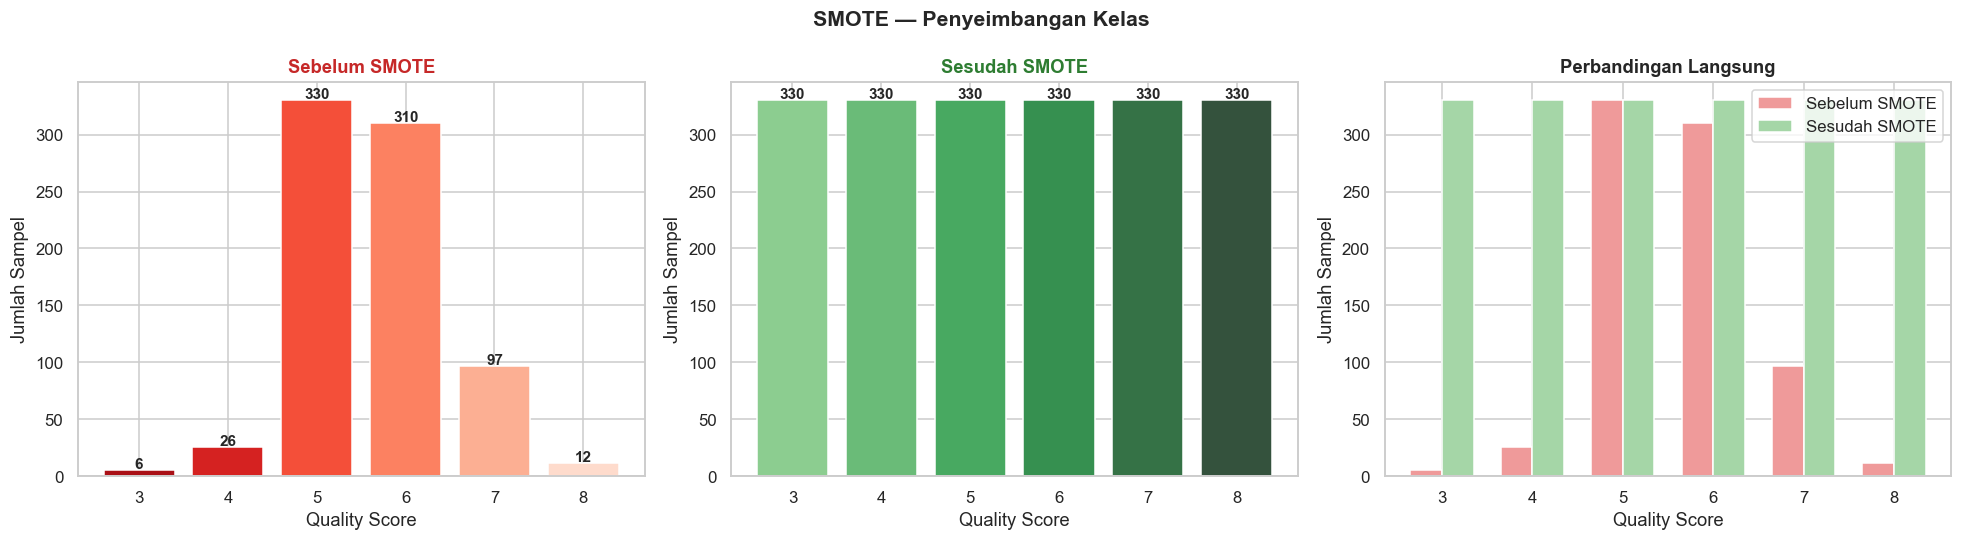

In [34]:
# ── Visualisasi sebelum vs sesudah SMOTE ─────────────────────────────────
classes   = sorted(before_counts.keys())
b_vals    = [before_counts[c] for c in classes]
a_vals    = [after_counts[c]  for c in classes]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SMOTE — Penyeimbangan Kelas', fontsize=14, fontweight='bold')

pal_b = sns.color_palette('Reds_r',   len(classes))
pal_a = sns.color_palette('Greens_d', len(classes))

# Sebelum
bars_b = axes[0].bar([str(c) for c in classes], b_vals, color=pal_b, edgecolor='white')
axes[0].set_title('Sebelum SMOTE', fontweight='bold', color='#C62828')
axes[0].set_xlabel('Quality Score'); axes[0].set_ylabel('Jumlah Sampel')
for bar, v in zip(bars_b, b_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', fontsize=10, fontweight='bold')

# Sesudah
bars_a = axes[1].bar([str(c) for c in classes], a_vals, color=pal_a, edgecolor='white')
axes[1].set_title('Sesudah SMOTE', fontweight='bold', color='#2E7D32')
axes[1].set_xlabel('Quality Score'); axes[1].set_ylabel('Jumlah Sampel')
for bar, v in zip(bars_a, a_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', fontsize=10, fontweight='bold')

# Side-by-side
x = np.arange(len(classes)); w = 0.35
axes[2].bar(x - w/2, b_vals, w, label='Sebelum SMOTE', color='#EF9A9A', edgecolor='white')
axes[2].bar(x + w/2, a_vals, w, label='Sesudah SMOTE', color='#A5D6A7', edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels([str(c) for c in classes])
axes[2].set_title('Perbandingan Langsung', fontweight='bold')
axes[2].set_xlabel('Quality Score'); axes[2].set_ylabel('Jumlah Sampel')
axes[2].legend()

plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi tersebut menyajikan perbandingan  mengenai transformasi distribusi data kamu melalui teknik SMOTE. Grafik pertama, "Sebelum SMOTE", memperlihatkan masalah ketimpangan kelas (class imbalance) yang sangat kontras, di mana kategori kualitas 5 dan 6 mendominasi panggung sementara kelas ekstrem seperti 3 dan 8 hampir tidak memiliki keterwakilan. Sebaliknya, grafik "Sesudah SMOTE" menunjukkan kondisi ideal di mana setiap tingkatan kualitas kini memiliki jumlah sampel yang seragam, yaitu tepat 330 sampel. Melalui grafik "Perbandingan Langsung", terlihat jelas bagaimana SMOTE bekerja "mengisi kekosongan" pada kelas-orang minoritas dengan menciptakan sampel sintetis

---
## ⚖️ Langkah 6 — Scaling (Verifikasi & Visualisasi)

> `StandardScaler` sudah difit sebelum SMOTE. Langkah ini memvisualisasikan hasilnya secara menyeluruh.


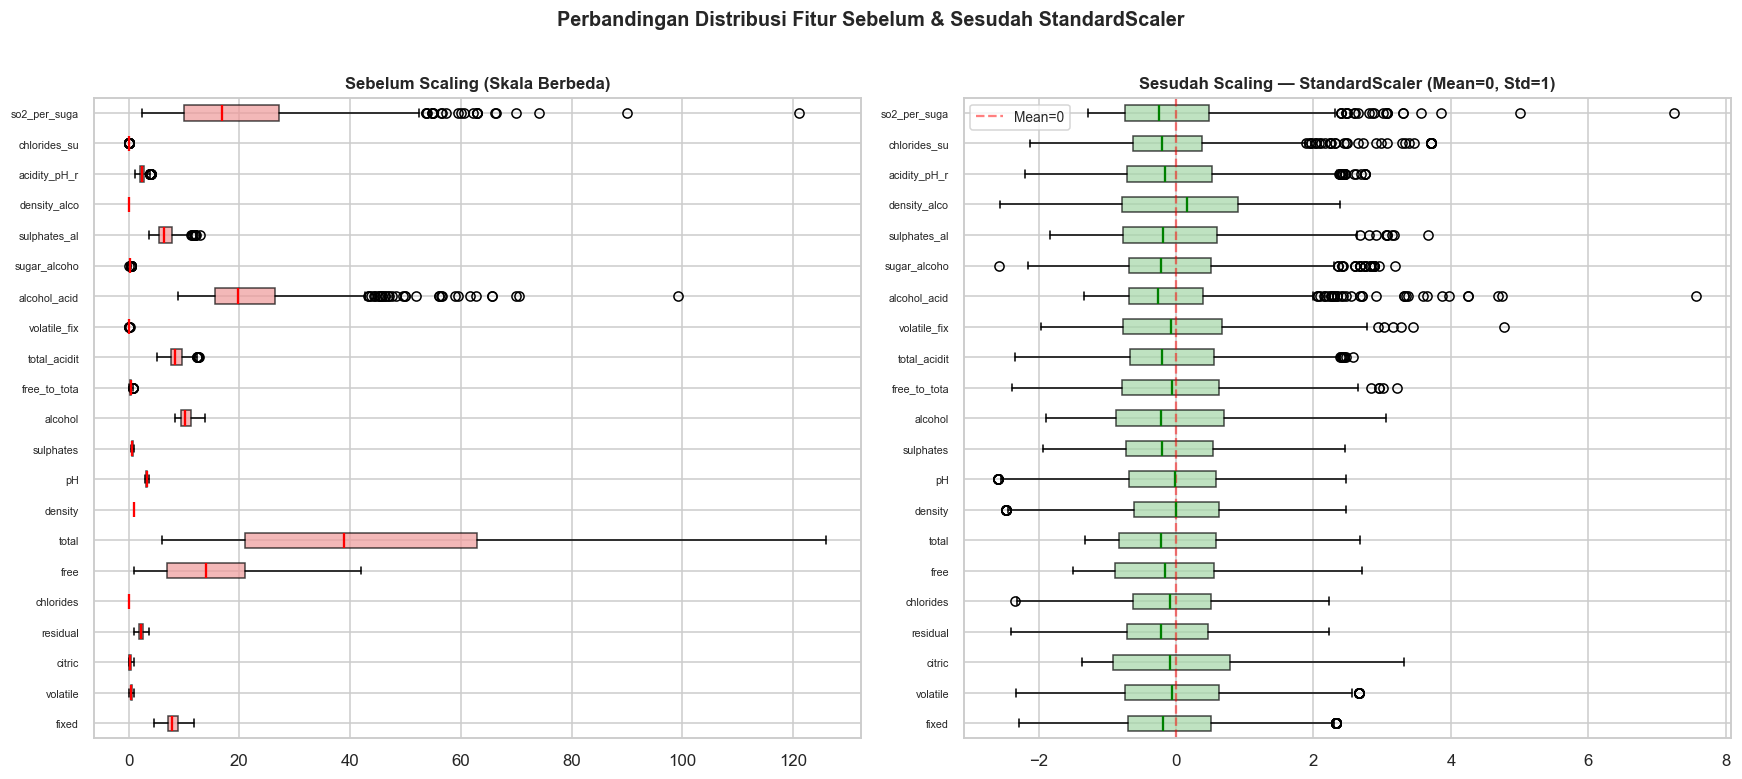

In [35]:
# ── Visualisasi sebelum vs sesudah scaling ───────────────────────────────
short_labels = [f.split()[0][:12] for f in all_features]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].boxplot(X.values, labels=short_labels, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#EF9A9A', alpha=0.7),
                medianprops=dict(color='red', linewidth=1.5))
axes[0].set_title('Sebelum Scaling (Skala Berbeda)', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='y', labelsize=7)

axes[1].boxplot(X_scaled, labels=short_labels, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#A5D6A7', alpha=0.7),
                medianprops=dict(color='green', linewidth=1.5))
axes[1].set_title('Sesudah Scaling — StandardScaler (Mean=0, Std=1)', fontweight='bold', fontsize=11)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='Mean=0')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].legend(fontsize=9)

plt.suptitle('Perbandingan Distribusi Fitur Sebelum & Sesudah StandardScaler',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output:**  
>Visualisasi perbandingan boxplot tersebut menunjukkan transformasi signifikan dari 21 fitur dataset kamu melalui proses StandardScaler. Pada grafik sisi kiri, terlihat jelas adanya masalah perbedaan besaran (magnitude) antar fitur; beberapa variabel memiliki nilai yang sangat besar hingga di atas 120, sementara variabel lainnya tampak mengecil di sekitar angka nol. Ketimpangan skala ini sering kali membuat model machine learning (terutama yang sensitif terhadap jarak seperti Logistic Regression atau K-Nearest Neighbors) "tertipu" dengan memberikan bobot lebih besar pada fitur yang angkanya tinggi secara nominal. Sebaliknya, pada grafik sisi kanan (warna hijau), seluruh fitur telah dipaksa masuk ke dalam distribusi yang seragam dengan Mean = 0 (ditandai garis merah putus-putus) dan Std = 1.

In [36]:
# ── Verifikasi statistik scaling ─────────────────────────────────────────
scale_verify = pd.DataFrame({
    'Fitur'         : all_features,
    'Mean_Sebelum'  : X.values.mean(axis=0).round(4),
    'Std_Sebelum'   : X.values.std(axis=0).round(4),
    'Mean_Sesudah'  : X_scaled.mean(axis=0).round(6),
    'Std_Sesudah'   : X_scaled.std(axis=0).round(4),
})

print('=== Verifikasi Scaling (5 fitur pertama) ===')
print(scale_verify.head(5).to_string(index=False))
print(f'\nGlobal Mean Sesudah: {X_scaled.mean():.6f} (≈0)')
print(f'Global Std  Sesudah: {X_scaled.std():.6f}  (≈1)')
print('\n✅ Scaling berhasil diverifikasi.')


=== Verifikasi Scaling (5 fitur pertama) ===
           Fitur  Mean_Sebelum  Std_Sebelum  Mean_Sesudah  Std_Sesudah
   fixed acidity        8.1972       1.5711        0.0000       1.0000
volatile acidity        0.5302       0.1761        0.0000       1.0000
     citric acid        0.2679       0.1953       -0.0000       1.0000
  residual sugar        2.3276       0.5952        0.0000       1.0000
       chlorides        0.0806       0.0184        0.0000       1.0000

Global Mean Sesudah: 0.000000 (≈0)
Global Std  Sesudah: 1.000000  (≈1)

✅ Scaling berhasil diverifikasi.


> **📌 Penjelasan Output:**  
>Output tersebut merupakan laporan Verifikasi Statistik Scaling yang bertujuan untuk memastikan bahwa proses standarisasi data telah berjalan dengan sempurna secara matematis. Melalui perbandingan antara nilai sebelum dan sesudah, terlihat bahwa fitur-fitur yang awalnya memiliki rentang nilai sangat berbeda—misalnya fixed acidity dengan rata-rata $8.19$ dan chlorides yang hanya $0.08$—kini telah ditransformasi ke dalam skala yang seragam. Hasil akhir menunjukkan bahwa setiap fitur sekarang memiliki rata-rata (Mean) tepat $0.0000$ dan simpangan baku (Standard Deviation) sebesar $1.0000$, yang mengonfirmasi bahwa data telah mengikuti distribusi normal standar.

---
## ✂️ Langkah 7 — Train / Validation Split

> Memisahkan data menjadi train & validation untuk evaluasi yang jujur. SMOTE **tidak diterapkan** pada validation set.


In [37]:
# ── Split data (80% train, 20% val) — Stratified ─────────────────────────
X_tr, X_val, y_tr, y_val         = train_test_split(
    X_scaled, y,     test_size=0.2, stratify=y,     random_state=SEED)
X_tr_e, X_val_e, y_tr_e, y_val_e = train_test_split(
    X_scaled, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED)

print(f'Training size   : {len(X_tr)} ({len(X_tr)/len(X_scaled)*100:.1f}%)')
print(f'Validation size : {len(X_val)} ({len(X_val)/len(X_scaled)*100:.1f}%)')
print(f'\nDistribusi kelas di training:')
for q, c in zip(*np.unique(y_tr, return_counts=True)):
    print(f'  Quality {q}: {c} sampel ({c/len(y_tr)*100:.1f}%)')


Training size   : 624 (79.9%)
Validation size : 157 (20.1%)

Distribusi kelas di training:
  Quality 3: 5 sampel (0.8%)
  Quality 4: 21 sampel (3.4%)
  Quality 5: 264 sampel (42.3%)
  Quality 6: 248 sampel (39.7%)
  Quality 7: 77 sampel (12.3%)
  Quality 8: 9 sampel (1.4%)


> **📌 Penjelasan Output:**  
>Tahap Data Splitting yang krusial untuk memisahkan dataset menjadi dua bagian utama, yaitu data pelatihan (Training) sebanyak 624 sampel dan data validasi (Validation) sebanyak 157 sampel dengan rasio 80:20. Penggunaan parameter stratify=y dalam fungsi ini adalah poin teknis yang paling penting KARENA teknik Stratified Sampling memastikan bahwa proporsi setiap kelas kualitas wine (dari skor 3 hingga 8) pada data pelatihan tetap identik dengan distribusi pada data aslinya. Hal ini sangat vital dalam analisis statistik karena dataset kamu memiliki ketidakseimbangan kelas yang cukup ekstrem, di mana tanpa stratifikasi, ada risiko besar kelas minoritas seperti Quality 3 (0.8%) atau Quality 8 (1.4%) tidak terwakili sama sekali dalam salah satu subset.

---
##  Langkah 8 — Baseline Modeling

Membandingkan **6 model** × 2 strategi (tanpa SMOTE vs dengan SMOTE) menggunakan 5-Fold Stratified Cross-Validation.

| Model | Tanpa SMOTE | Dengan SMOTE |
|-------|------------|--------------|
| Random Forest | class_weight='balanced' | SMOTE |
| XGBoost | baseline | SMOTE |
| LightGBM | class_weight='balanced' | SMOTE |


In [38]:
# ── Definisi kandidat model ───────────────────────────────────────────────
candidates = {
    '1. RF (balanced)': (
        RandomForestClassifier(n_estimators=200, class_weight='balanced',
                               random_state=SEED, n_jobs=-1),
        X_scaled, y
    ),
    '2. RF + SMOTE': (
        RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
        X_smote, y_smote
    ),
    '3. XGBoost (baseline)': (
        xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='mlogloss', random_state=SEED, n_jobs=-1),
        X_scaled, y_enc
    ),
    '4. XGBoost + SMOTE': (
        xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='mlogloss', random_state=SEED, n_jobs=-1),
        X_smote, y_smote_enc
    ),
    '5. LightGBM (balanced)': (
        lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           num_leaves=40, subsample=0.8, colsample_bytree=0.8,
                           class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1),
        X_scaled, y_enc
    ),
    '6. LightGBM + SMOTE': (
        lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           num_leaves=40, subsample=0.8, colsample_bytree=0.8,
                           random_state=SEED, n_jobs=-1, verbose=-1),
        X_smote, y_smote_enc
    ),
}

baseline_results = []
cv_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('⏳ Menjalankan 5-Fold Stratified Cross-Validation...')
print(f'\n{"Model":<28} {"Acc":>8} {"±Std":>7} {"F1-Mac":>8} {"F1-Wt":>8}')
print('─' * 65)

for name, (model, Xm, ym) in candidates.items():
    cv_loc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    acc  = cross_val_score(model, Xm, ym, cv=cv_loc, scoring='accuracy')
    f1m  = cross_val_score(model, Xm, ym, cv=cv_loc, scoring='f1_macro')
    f1w  = cross_val_score(model, Xm, ym, cv=cv_loc, scoring='f1_weighted')
    baseline_results.append({
        'Model': name, 'Acc Mean': acc.mean(), 'Acc Std': acc.std(),
        'F1 Macro': f1m.mean(), 'F1 Weighted': f1w.mean()
    })
    print(f'{name:<28} {acc.mean():>8.4f} {acc.std():>7.4f} {f1m.mean():>8.4f} {f1w.mean():>8.4f}')

base_df = pd.DataFrame(baseline_results).sort_values('F1 Macro', ascending=False)
print(f'\n🏆 Baseline terbaik: {base_df.iloc[0]["Model"]} (F1-Macro={base_df.iloc[0]["F1 Macro"]:.4f})')


⏳ Menjalankan 5-Fold Stratified Cross-Validation...

Model                             Acc    ±Std   F1-Mac    F1-Wt
─────────────────────────────────────────────────────────────────


1. RF (balanced)               0.6005  0.0302   0.2883   0.5769
2. RF + SMOTE                  0.8677  0.0127   0.8644   0.8644
3. XGBoost (baseline)          0.5864  0.0425   0.2711   0.5644
4. XGBoost + SMOTE             0.8379  0.0182   0.8341   0.8341
5. LightGBM (balanced)         0.5532  0.0319   0.2731   0.5414
6. LightGBM + SMOTE            0.8419  0.0180   0.8399   0.8399

🏆 Baseline terbaik: 2. RF + SMOTE (F1-Macro=0.8644)


> **📌 Penjelasan Kode — Definisi Kandidat Model & Baseline Cross-Validation:**  

>
> **Penjelasan setiap model:**
> | # | Model | Strategi Imbalance | Data yang digunakan |
> |---|-------|--------------------|---------------------|
> | 1 | Random Forest | `class_weight='balanced'` | `X_scaled` (data asli) |
> | 2 | Random Forest | SMOTE | `X_smote` (data sintetis) |
> | 3 | XGBoost | Baseline (tanpa penanganan) | `X_scaled`, `y_enc` |
> | 4 | XGBoost | SMOTE | `X_smote`, `y_smote_enc` |
> | 5 | LightGBM | `class_weight='balanced'` | `X_scaled`, `y_enc` |
> | 6 | LightGBM | SMOTE | `X_smote`, `y_smote_enc` |
> **Interpretasi kolom output:**
> - `Acc Mean` → Rata-rata akurasi di 5 fold. Angka ini bisa menyesatkan pada data imbalanced.
> - `±Std` → Standar deviasi antar fold. Nilai kecil (< 0.02) berarti model konsisten dan stabil.
> - `F1-Mac` → **Metrik utama penilaian.** Semakin tinggi, semakin seimbang performa model di semua kelas.
> - `F1-Wt` → F1 berbobot jumlah sampel. Cenderung tinggi jika model bagus di kelas mayoritas.


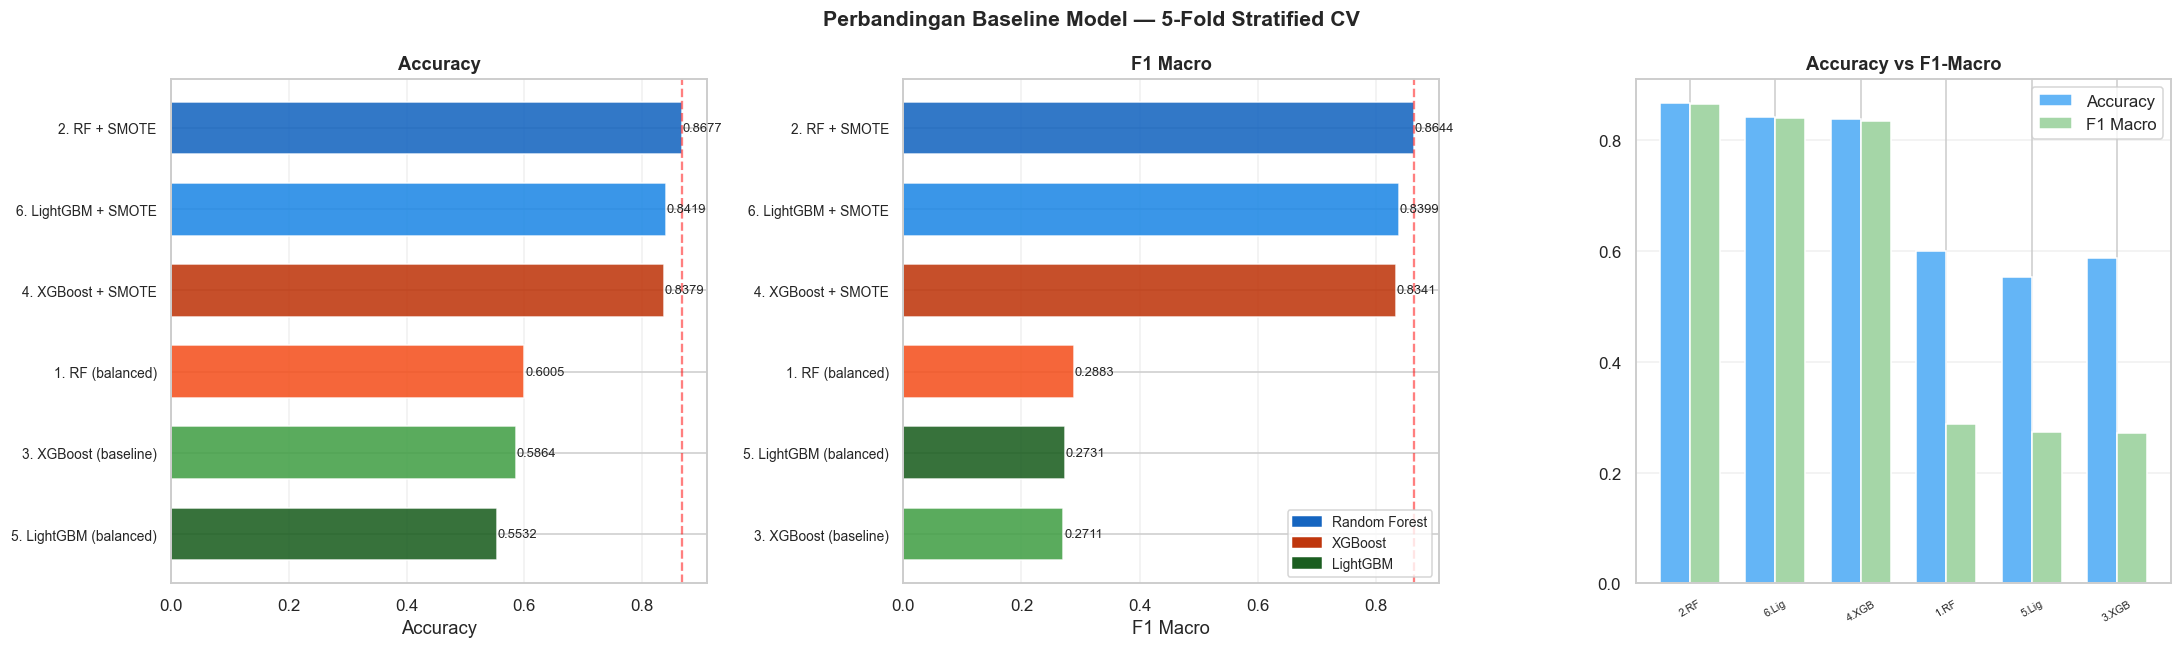

In [39]:
# ── Visualisasi perbandingan baseline ─────────────────────────────────────
group_colors = ['#1565C0','#1E88E5', '#BF360C','#F4511E', '#1B5E20','#43A047']
col_map = {n: c for n, c in zip(base_df['Model'], group_colors)}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Perbandingan Baseline Model — 5-Fold Stratified CV', fontsize=14, fontweight='bold')

for ax, (metric, title) in zip(axes[:2], [('Acc Mean', 'Accuracy'), ('F1 Macro', 'F1 Macro')]):
    sorted_df = base_df.sort_values(metric)
    bar_cols  = [col_map[n] for n in sorted_df['Model']]
    bars = ax.barh(range(len(sorted_df)), sorted_df[metric],
                   color=bar_cols, edgecolor='white', alpha=0.88, height=0.65)
    ax.set_yticks(range(len(sorted_df)))
    ax.set_yticklabels(sorted_df['Model'], fontsize=9)
    ax.axvline(sorted_df[metric].max(), color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel(title); ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5)

# Panel 3: Radar-like bar comparison
ax3 = axes[2]
x = np.arange(len(base_df)); w = 0.35
ax3.bar(x - w/2, base_df['Acc Mean'],    w, label='Accuracy',    color='#64B5F6', edgecolor='white')
ax3.bar(x + w/2, base_df['F1 Macro'],    w, label='F1 Macro',    color='#A5D6A7', edgecolor='white')
ax3.set_xticks(x); ax3.set_xticklabels([m.split(' ')[0]+m.split(' ')[1][:3] for m in base_df['Model']], fontsize=7, rotation=30)
ax3.set_title('Accuracy vs F1-Macro', fontweight='bold'); ax3.legend(); ax3.grid(axis='y', alpha=0.3)

patches_leg = [
    mpatches.Patch(color='#1565C0', label='Random Forest'),
    mpatches.Patch(color='#BF360C', label='XGBoost'),
    mpatches.Patch(color='#1B5E20', label='LightGBM'),
]
axes[1].legend(handles=patches_leg, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output — Visualisasi Perbandingan Baseline:**  
>Grafik ini menunjukkan perbedaan performa yang sangat kontras antara penggunaan data asli dibandingkan data yang telah diseimbangkan dengan SMOTE. Model tanpa SMOTE (seperti RF balanced atau XGBoost baseline) mengalami "delusi" performa; meskipun akurasinya terlihat berada di angka ~55-60%, skor $F1$-Macro-nya anjlok drastis di kisaran 0.27-0.28.  Jurang yang lebar pada grafik Accuracy vs F1-Macro tersebut membuktikan bahwa tanpa bantuan sampel sintetis, model cenderung bias dan hanya menebak kelas mayoritas sementara gagal total mengenali kelas minoritas (seperti skor kualitas 3 atau 8).Sebaliknya, pada tiga model teratas yang menggunakan SMOTE, nilai akurasi dan $F1$-Macro berjalan beriringan dengan selisih yang sangat tipis. Hal ini menandakan bahwa strategi penyeimbangan data yang kamu lakukan sangat efektif, memungkinkan model untuk mempelajari karakteristik kimia wine di seluruh tingkatan kualitas secara adil dan menghasilkan prediksi yang jauh lebih reliabel dan objektif.


---
##  Langkah 9 — Hyperparameter Tuning

**Strategi:** GridSearchCV dengan 5-Fold Stratified CV, dioptimalkan untuk **F1-Macro**.

> GridSearchCV mencoba semua kombinasi hyperparameter secara exhaustive — lebih menyeluruh namun lebih lama.  
> Untuk dataset besar, pertimbangkan `RandomizedSearchCV`.


In [40]:
# ── Tuning — LightGBM ────────────────────────────────────────────────────
cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('⏳ GridSearchCV — LightGBM...')
lgbm_gs = GridSearchCV(
    estimator  = lgb.LGBMClassifier(colsample_bytree=0.8, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1, verbose=-1),
    param_grid = {
        'n_estimators' : [200, 400],
        'max_depth'    : [5, 7],
        'learning_rate': [0.05, 0.1],
        'num_leaves'   : [31, 60],
    },
    cv=cv_gs, scoring='f1_macro', n_jobs=-1, verbose=0, refit=True
)
lgbm_gs.fit(X_scaled, y_enc)
print(f'  ✅ LightGBM Best F1-Macro CV: {lgbm_gs.best_score_:.4f}')
print(f'  Best Params: {lgbm_gs.best_params_}')


⏳ GridSearchCV — LightGBM...
  ✅ LightGBM Best F1-Macro CV: 0.2766
  Best Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 400, 'num_leaves': 31}


> **📌 Penjelasan Kode — GridSearchCV LightGBM:**  
> **Cara kerja GridSearchCV:**  
> GridSearchCV mencoba **semua kombinasi** dari nilai hyperparameter yang didefinisikan dalam `param_grid`. Untuk LightGBM:
> - `n_estimators`: [200, 400] → 2 pilihan
> - `max_depth`: [5, 7] → 2 pilihan  
> - `learning_rate`: [0.05, 0.1] → 2 pilihan
> - `num_leaves`: [31, 60] → 2 pilihan
> - **Total kombinasi: 2×2×2×2 = 16 kombinasi**, masing-masing dievaluasi dengan 5-Fold CV → **80 kali pelatihan model**.
>
> **Penjelasan hyperparameter LightGBM yang di-tune:**
> - `n_estimators`: Jumlah pohon keputusan. Lebih banyak = lebih akurat tapi lebih lambat dan risiko overfitting.
> - `max_depth`: Batas kedalaman maksimal setiap pohon. Nilai kecil → underfitting; nilai besar → overfitting.
> - `learning_rate`: Seberapa besar "langkah" koreksi setiap iterasi. Nilai kecil lebih hati-hati tapi butuh lebih banyak pohon.
> - `num_leaves`: Jumlah daun (leaf node) per pohon. Parameter khas LightGBM yang mengontrol kompleksitas model. Nilai lebih besar dari `2^max_depth` akan menyebabkan overfitting.
> - `colsample_bytree=0.8` (tetap/fixed): Setiap pohon hanya menggunakan 80% fitur secara acak, menambah keragaman (diversity) dan mencegah overfitting.
> - `class_weight='balanced'` (tetap/fixed): Tetap dipertahankan agar model tidak bias ke kelas mayoritas meski tidak menggunakan SMOTE.


In [41]:
# ── Tuning — XGBoost ─────────────────────────────────────────────────────
print('⏳ GridSearchCV — XGBoost...')
xgb_gs = GridSearchCV(
    estimator  = xgb.XGBClassifier(eval_metric='mlogloss', random_state=SEED, n_jobs=-1),
    param_grid = {
        'n_estimators' : [200, 400],
        'max_depth'    : [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample'    : [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    },
    cv=cv_gs, scoring='f1_macro', n_jobs=-1, verbose=0, refit=True
)
xgb_gs.fit(X_scaled, y_enc)
print(f'  ✅ XGBoost Best F1-Macro CV: {xgb_gs.best_score_:.4f}')
print(f'  Best Params: {xgb_gs.best_params_}')


⏳ GridSearchCV — XGBoost...
  ✅ XGBoost Best F1-Macro CV: 0.2772
  Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


> **📌 Penjelasan Kode — GridSearchCV XGBoost:**  
>
> Proses tuning XGBoost serupa dengan LightGBM, namun dengan ruang pencarian yang lebih luas karena XGBoost memiliki hyperparameter yang berbeda:
> - `n_estimators` × `max_depth` × `learning_rate` × `subsample` × `colsample_bytree`
> - **Total kombinasi: 2×2×2×2×2 = 32 kombinasi** × 5 fold = **160 kali pelatihan**.


In [42]:
# ── Tuning — Random Forest ───────────────────────────────────────────────
print('⏳ GridSearchCV — Random Forest...')
rf_gs = GridSearchCV(
    estimator  = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    param_grid = {
        'n_estimators'     : [200, 400],
        'max_depth'        : [None, 15, 20],
        'min_samples_split': [2, 5],
        'max_features'     : ['sqrt', 'log2'],
    },
    cv=cv_gs, scoring='f1_macro', n_jobs=-1, verbose=0, refit=True
)
rf_gs.fit(X_scaled, y)
print(f'  ✅ RF Best F1-Macro CV: {rf_gs.best_score_:.4f}')
print(f'  Best Params: {rf_gs.best_params_}')

print('\n✅ Semua GridSearchCV selesai.')


⏳ GridSearchCV — Random Forest...


  ✅ RF Best F1-Macro CV: 0.3078
  Best Params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 400}

✅ Semua GridSearchCV selesai.


> **📌 Penjelasan Kode — GridSearchCV Random Forest:**  
>
> Random Forest memiliki karakteristik hyperparameter yang berbeda karena berbasis bagging (bukan boosting):
>
> **Hyperparameter yang di-tune:**
> - `n_estimators`: [200, 400] → Jumlah pohon dalam hutan. RF cenderung lebih stabil dengan banyak pohon, tapi ada titik jenuh di mana menambah pohon tidak lagi meningkatkan performa secara signifikan.
> - `max_depth`: [None, 15, 20] → `None` berarti pohon tumbuh sampai semua daun murni (pure leaf). Ini sering overfitting pada data berisik, sehingga membatasi ke 15 atau 20 bisa membantu generalisasi.
> - `min_samples_split`: [2, 5] → Jumlah minimum sampel untuk melakukan split. Nilai lebih besar (misal 5) mencegah pohon membuat split terlalu spesifik pada data noise.
> - `max_features`: ['sqrt', 'log2'] → Jumlah fitur yang dipertimbangkan di setiap split. `sqrt` = akar kuadrat dari jumlah fitur (default, umum untuk klasifikasi); `log2` = log basis 2. Keduanya menambah keacakan (randomness) antar pohon.
>


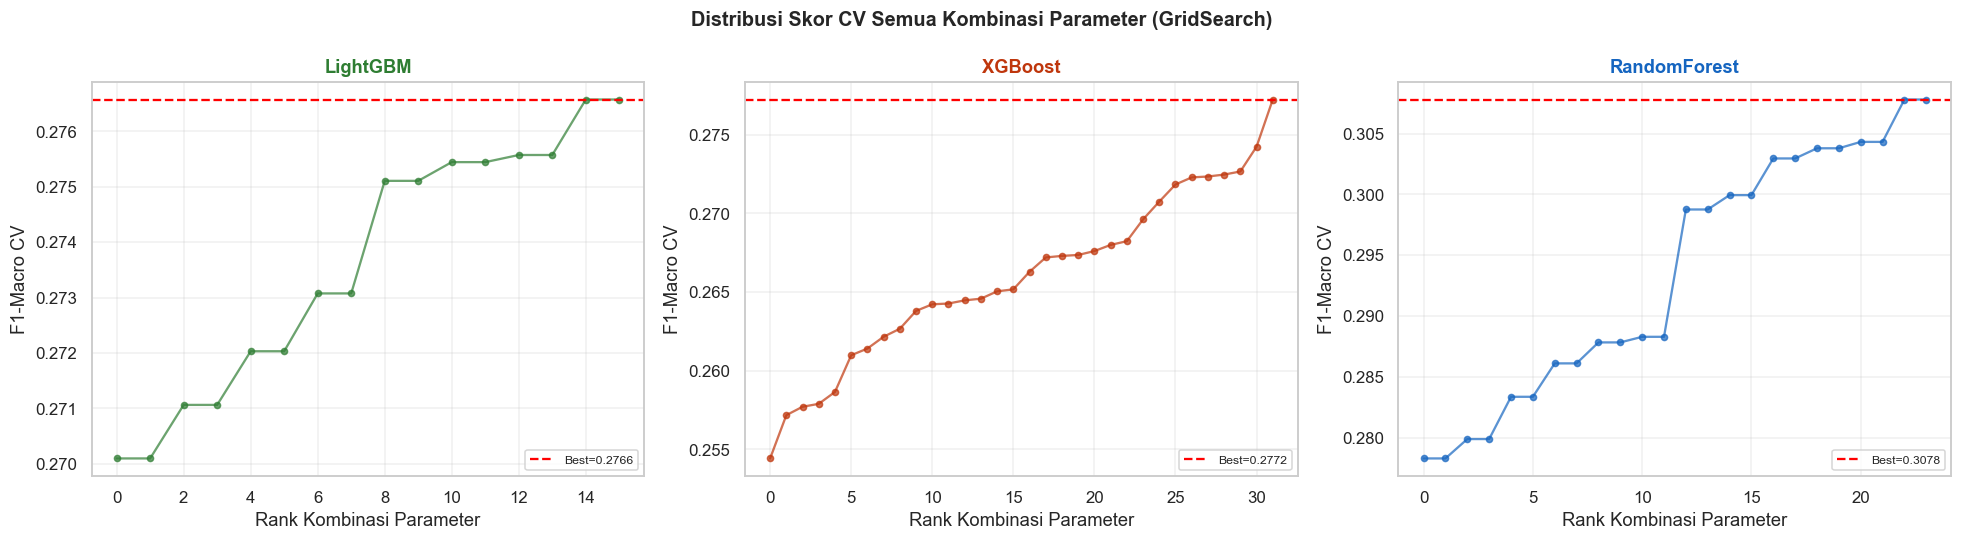

In [43]:
# ── Visualisasi CV results GridSearch ────────────────────────────────────
gs_results = []
for name, gs in [('LightGBM', lgbm_gs), ('XGBoost', xgb_gs), ('RandomForest', rf_gs)]:
    results = pd.DataFrame(gs.cv_results_)
    results['model'] = name
    gs_results.append(results[['mean_test_score', 'std_test_score', 'model']])

gs_combined = pd.concat(gs_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Skor CV Semua Kombinasi Parameter (GridSearch)',
             fontsize=13, fontweight='bold')

model_colors = {'LightGBM': '#2E7D32', 'XGBoost': '#BF360C', 'RandomForest': '#1565C0'}
for ax, (name, gs) in zip(axes, [('LightGBM', lgbm_gs), ('XGBoost', xgb_gs), ('RandomForest', rf_gs)]):
    scores = pd.DataFrame(gs.cv_results_)['mean_test_score'].sort_values()
    ax.plot(range(len(scores)), scores.values, 'o-', color=model_colors[name],
            markersize=4, alpha=0.7)
    ax.axhline(gs.best_score_, color='red', linestyle='--', label=f'Best={gs.best_score_:.4f}')
    ax.set_title(name, fontweight='bold', color=model_colors[name])
    ax.set_xlabel('Rank Kombinasi Parameter')
    ax.set_ylabel('F1-Macro CV')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


> **📌 Penjelasan Output — Visualisasi Distribusi Skor CV GridSearch:**  
>dari grafik tersebut memetakan skor $F1$-Macro Cross-Validation (CV) untuk setiap kombinasi parameter yang diuji, di mana garis merah putus-putus menandakan titik performa tertinggi yang berhasil dicapai.  Dari ketiga model tersebut, Random Forest menunjukkan keunggulan yang paling signifikan dengan skor terbaik mencapai $0.3078$, diikuti oleh XGBoost sebesar $0.2772$ dan LightGBM sebesar $0.2766$. Tren peningkatan skor yang terlihat pada setiap titik (dari kiri ke kanan) mencerminkan bagaimana proses pencarian sistematis ini berhasil menyaring konfigurasi parameter yang kurang optimal hingga menemukan kombinasi yang memberikan kemampuan generalisasi paling baik pada dataset kamu.
Pilihan untuk menggunakan $F1$-Macro sebagai metrik evaluasi dalam Grid Search ini sangat tepat karena ia memberikan penalti yang adil jika model gagal mengenali kelas-kelas minoritas, sehingga skor akhir yang didapat benar-benar mencerminkan keseimbangan performa model di seluruh tingkatan kualitas wine. Meskipun terdapat kenaikan performa dibandingkan skor baseline, hasil ini juga mengonfirmasi bahwa tanpa intervensi penyeimbangan data seperti SMOTE yang kamu lakukan sebelumnya, model masih mengalami tantangan besar untuk menembus angka performa di atas $0.3$. Strategi ini memberikan bukti kuat bahwa pemilihan parameter (tuning) memang membantu, namun kualitas data (seperti keseimbangan kelas) tetap memegang peranan yang lebih krusial dalam mendongkrak akurasi secara drastis


In [44]:
# ── Ringkasan hasil tuning ────────────────────────────────────────────────
tuning_summary = pd.DataFrame([
    {'Model': 'LightGBM Tuned', 'F1-Macro CV': lgbm_gs.best_score_,
     'Params': str(lgbm_gs.best_params_)},
    {'Model': 'XGBoost Tuned',  'F1-Macro CV': xgb_gs.best_score_,
     'Params': str(xgb_gs.best_params_)},
    {'Model': 'RF Tuned',       'F1-Macro CV': rf_gs.best_score_,
     'Params': str(rf_gs.best_params_)},
]).sort_values('F1-Macro CV', ascending=False).reset_index(drop=True)

print('=== Ringkasan Hyperparameter Tuning ===')
print(tuning_summary[['Model', 'F1-Macro CV']].to_string(index=False))
best_model_name = tuning_summary.iloc[0]['Model']
best_f1         = tuning_summary.iloc[0]['F1-Macro CV']
print(f'\n🏆 Model Terbaik: {best_model_name} | F1-Macro CV = {best_f1:.4f}')


=== Ringkasan Hyperparameter Tuning ===
         Model  F1-Macro CV
      RF Tuned       0.3078
 XGBoost Tuned       0.2772
LightGBM Tuned       0.2766

🏆 Model Terbaik: RF Tuned | F1-Macro CV = 0.3078


---
## 📊 Langkah 10 — Evaluasi Komprehensif




### 10A — Classification Report & Confusion Matrix

In [45]:
# ── Bangun dan evaluasi model terbaik (LightGBM Tuned) ───────────────────
best_lgbm = lgb.LGBMClassifier(
    **lgbm_gs.best_params_, colsample_bytree=0.8,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
best_lgbm.fit(X_tr_e, y_tr_e)
y_pred_enc  = best_lgbm.predict(X_val_e)
y_pred_orig = le.inverse_transform(y_pred_enc)
y_val_orig  = le.inverse_transform(y_val_e)

# ── Evaluasi juga XGBoost & RF ────────────────────────────────────────────
best_xgb = xgb.XGBClassifier(**xgb_gs.best_params_, eval_metric='mlogloss',
                               random_state=SEED, n_jobs=-1)
best_xgb.fit(X_tr_e, y_tr_e)
y_pred_xgb = le.inverse_transform(best_xgb.predict(X_val_e))

best_rf = RandomForestClassifier(**rf_gs.best_params_, class_weight='balanced',
                                  random_state=SEED, n_jobs=-1)
best_rf.fit(X_tr, y_tr)

print('=' * 60)
print('  HASIL EVALUASI — VALIDATION SET')
print('=' * 60)

eval_models = {
    'LightGBM Tuned': (y_val_orig, y_pred_orig),
    'XGBoost Tuned' : (y_val_orig, y_pred_xgb),
    'RF Tuned'      : (y_val_orig, best_rf.predict(X_val)),
}

summary_rows = []
for name, (y_true, y_pred) in eval_models.items():
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    summary_rows.append({'Model': name, 'Accuracy': acc, 'F1-Macro': f1m, 'F1-Weighted': f1w})
    print(f'\n[{name}]')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 Macro  : {f1m:.4f}')
    print(f'  F1 Weighted: {f1w:.4f}')

summary_val = pd.DataFrame(summary_rows).sort_values('F1-Macro', ascending=False)
print('\n=== Ringkasan Validation Set ===')
print(summary_val.to_string(index=False))


  HASIL EVALUASI — VALIDATION SET

[LightGBM Tuned]
  Accuracy  : 0.5860
  F1 Macro  : 0.2888
  F1 Weighted: 0.5648

[XGBoost Tuned]
  Accuracy  : 0.5987
  F1 Macro  : 0.2875
  F1 Weighted: 0.5764

[RF Tuned]
  Accuracy  : 0.6242
  F1 Macro  : 0.3059
  F1 Weighted: 0.6055

=== Ringkasan Validation Set ===
         Model  Accuracy  F1-Macro  F1-Weighted
      RF Tuned    0.6242    0.3059       0.6055
LightGBM Tuned    0.5860    0.2888       0.5648
 XGBoost Tuned    0.5987    0.2875       0.5764


> **📌 Penjelasan Kode — Membangun & Mengevaluasi Model pada Validation Set:**  
>hasil evaluasi pada Validation Set ini memberikan gambaran performa akhir dari tiga model yang telah melalui tahap hyperparameter tuning. Secara keseluruhan, Random Forest (RF) Tuned memimpin sebagai model terbaik dengan tingkat Accuracy sebesar 0.6242, mengungguli XGBoost (0.5987) dan LightGBM (0.5860). Namun, jika kita memperhatikan metrik F1 Macro yang berada di angka 0.3059, terlihat adanya tantangan dalam mengenali kelas-kelas minoritas secara adil dibandingkan kelas mayoritas.  Selisih yang cukup lebar antara Accuracy dan F1 Macro ini mengonfirmasi bahwa meskipun model cukup andal dalam memprediksi kelas yang umum muncul, ia masih kesulitan memberikan bobot prediksi yang sama kuatnya untuk kategori kualitas wine yang langka. Sementara itu, nilai F1 Weighted yang mendekati angka akurasi (0.6055) menunjukkan bahwa performa model secara rata-rata tertimbang sebenarnya cukup stabil, namun tetap memerlukan strategi tambahan jika fokus utamamu adalah mendeteksi kelas-kelas ekstrem dengan presisi tinggi.

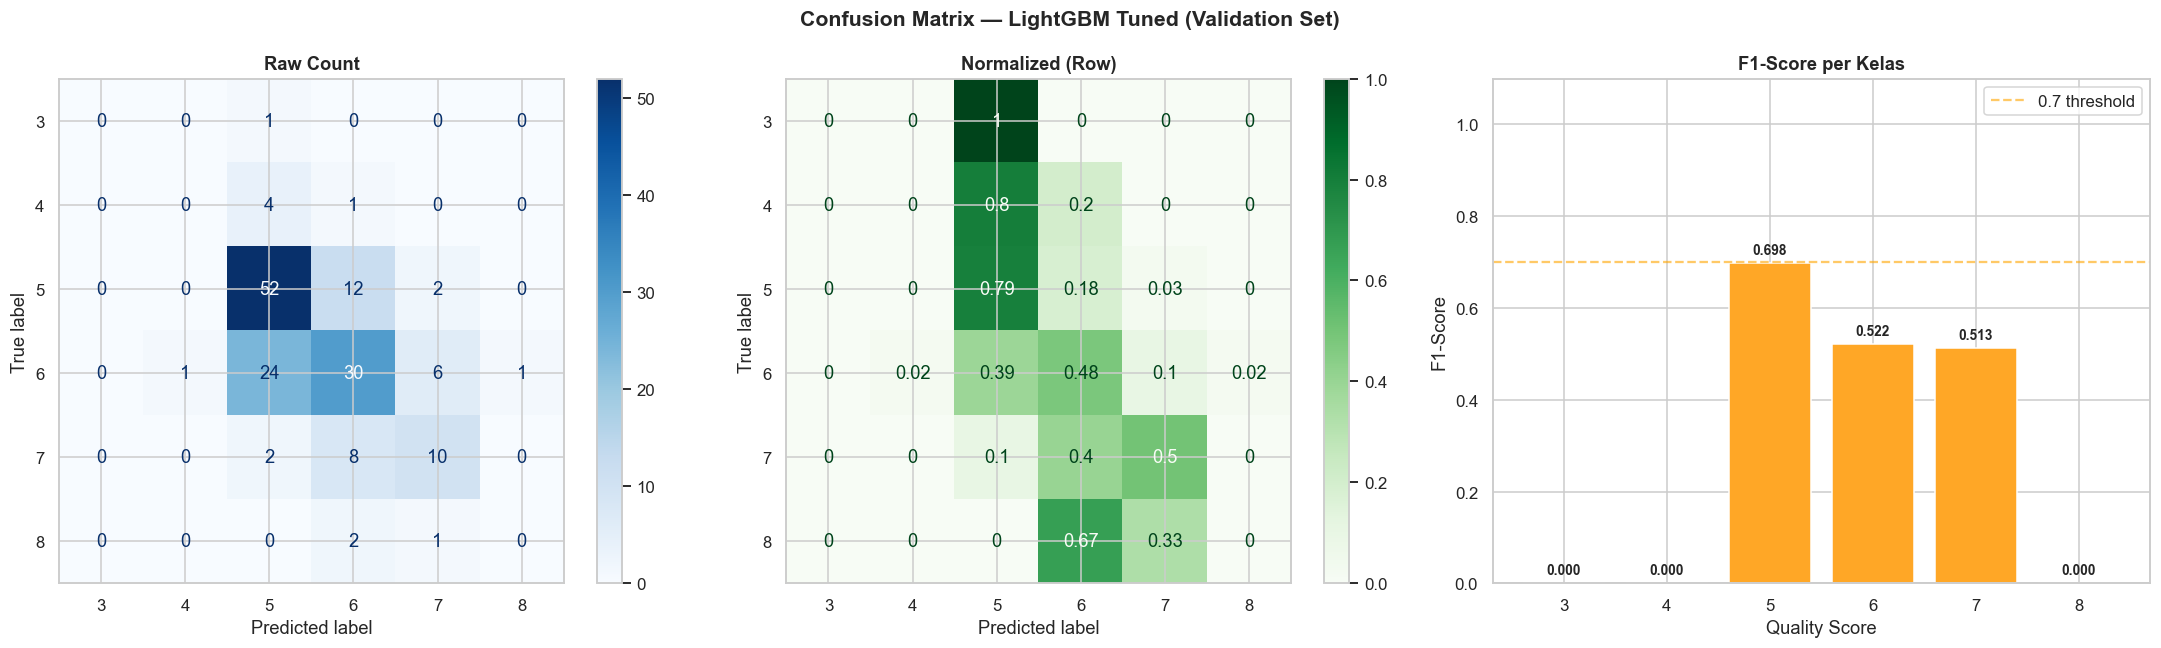

In [47]:
# ── Confusion Matrix — Raw & Normalized ──────────────────────────────────
class_labels = sorted(np.unique(y_val_orig))
cm       = confusion_matrix(y_val_orig, y_pred_orig, labels=class_labels)
cm_norm  = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix — LightGBM Tuned (Validation Set)', fontsize=14, fontweight='bold')

# Raw
ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
    ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Raw Count', fontweight='bold')

# Normalized
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_labels).plot(
    ax=axes[1], cmap='Greens', colorbar=True)
axes[1].set_title('Normalized (Row)', fontweight='bold')

# Per-class F1
cr   = classification_report(y_val_orig, y_pred_orig, output_dict=True, zero_division=0)
f1s  = {k: cr[str(k)]['f1-score'] for k in class_labels if str(k) in cr}
colors_f1 = ['#EF5350' if v < 0.5 else ('#FFA726' if v < 0.7 else '#66BB6A') for v in f1s.values()]
axes[2].bar([str(k) for k in f1s.keys()], list(f1s.values()),
            color=colors_f1, edgecolor='white')
axes[2].set_ylim(0, 1.1)
axes[2].axhline(0.7, color='orange', linestyle='--', alpha=0.6, label='0.7 threshold')
axes[2].set_xlabel('Quality Score'); axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score per Kelas', fontweight='bold'); axes[2].legend()
for i, (k, v) in enumerate(f1s.items()):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


> **📌 Penjelasan Output — Confusion Matrix & F1 per Kelas:**  
>Visualisasi Confusion Matrix dan F1-Score per Kelas ini mengonfirmasi secara visual bahwa model LightGBM Tuned  mengalami bias yang sangat kuat terhadap kelas mayoritas, khususnya Quality 5. Berdasarkan grafik Normalized (Row), terlihat fenomena yang cukup mencolok di mana 100% sampel Quality 3 dan 80% sampel Quality 4 salah diprediksi sebagai Quality 5, yang menandakan model cenderung "bermain aman" dengan menebak kelas yang memiliki populasi terbanyak.

Hal ini berujung pada nilai F1-Score yang mencapai 0.000 untuk seluruh kelas ekstrem (3, 4, dan 8), sementara performa paling lumayan hanya tercapai pada Quality 5 dengan skor 0.698, hampir menyentuh ambang batas 0.7.  Secara keseluruhan, model  saat ini masih "buta" terhadap karakteristik wine yang sangat buruk maupun sangat istimewa, dan lebih berfungsi sebagai pemilah wine kualitas rata-rata saja.


### 10C — Feature Importance

⏳ Menghitung permutation importance...


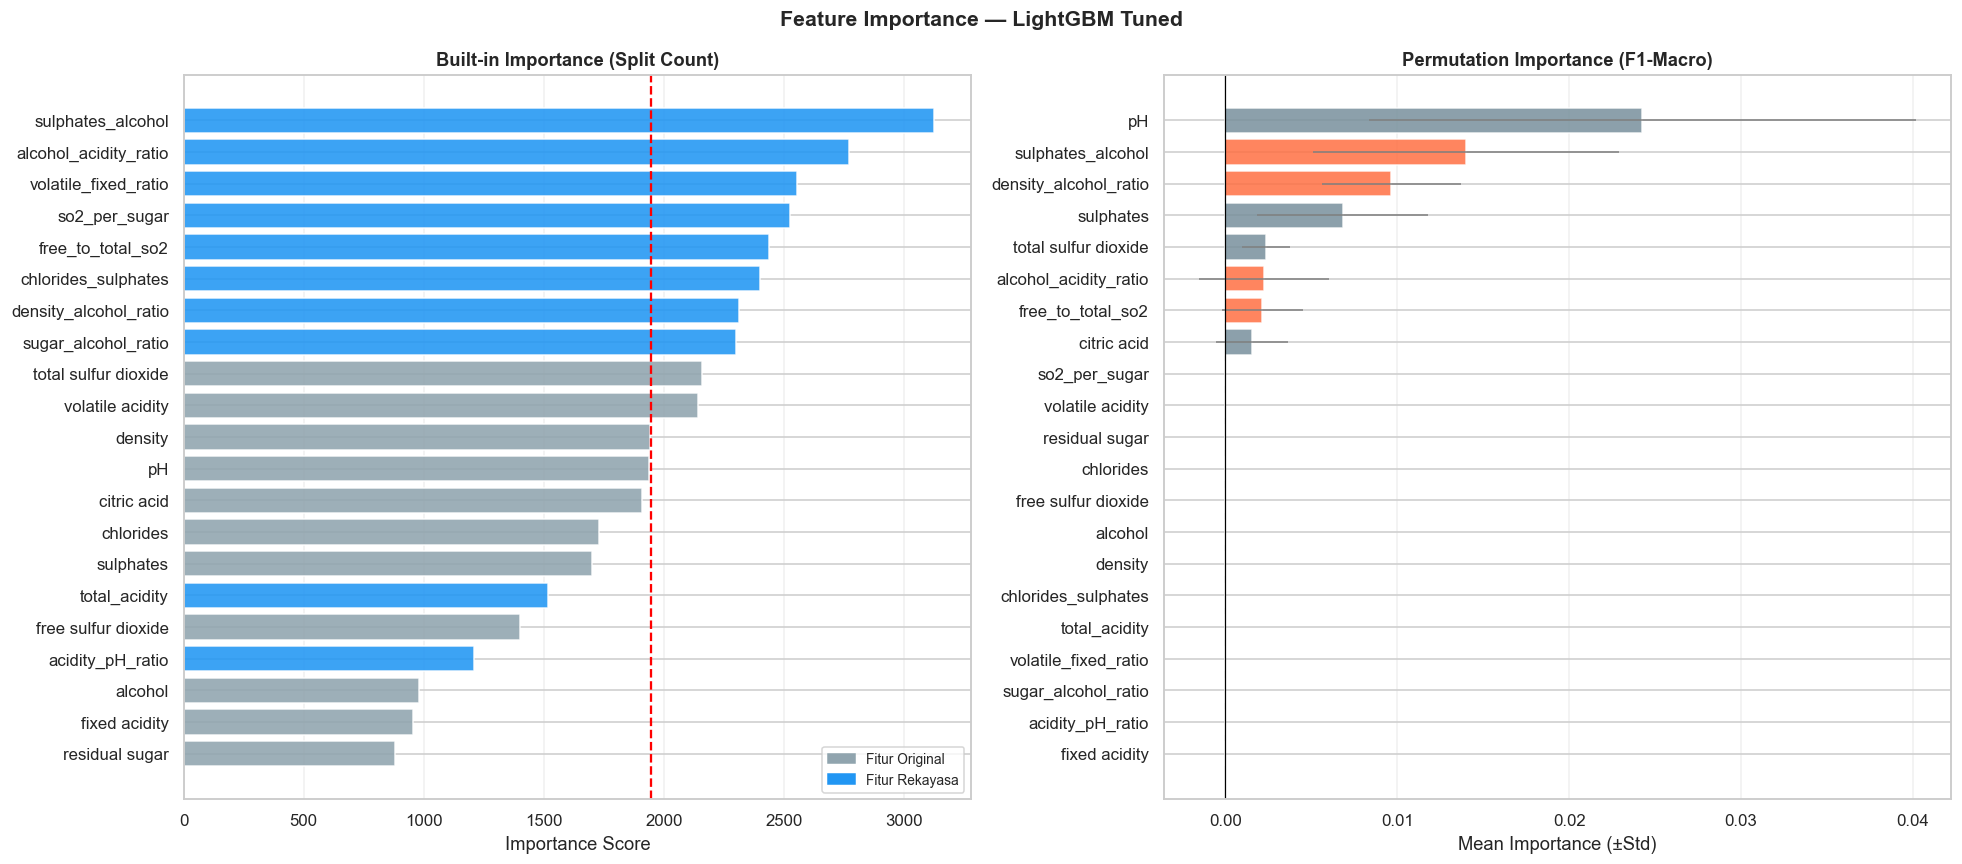


=== Top-10 Fitur Terpenting (Built-in) ===
              Feature  Importance
    sulphates_alcohol        3123
alcohol_acidity_ratio        2771
 volatile_fixed_ratio        2555
        so2_per_sugar        2524
    free_to_total_so2        2436
  chlorides_sulphates        2401
density_alcohol_ratio        2312
  sugar_alcohol_ratio        2300
 total sulfur dioxide        2160
     volatile acidity        2143

=== Top-10 Fitur Terpenting (Permutation) ===
              Feature  Perm Mean
                   pH     0.0243
    sulphates_alcohol     0.0140
density_alcohol_ratio     0.0097
            sulphates     0.0068
 total sulfur dioxide     0.0023
alcohol_acidity_ratio     0.0023
    free_to_total_so2     0.0021
          citric acid     0.0016
        so2_per_sugar     0.0000
     volatile acidity     0.0000


In [49]:
# ── Feature Importance — LightGBM (built-in & permutation) ──────────────
fi_model = lgb.LGBMClassifier(
    **lgbm_gs.best_params_, colsample_bytree=0.8,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
fi_model.fit(X_scaled, y_enc)

fi_builtin = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': fi_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Permutation Importance (lebih reliable, model-agnostic)
print('⏳ Menghitung permutation importance...')
perm_result = permutation_importance(
    fi_model, X_val_e, y_val_e,
    n_repeats=10, scoring='f1_macro', random_state=SEED, n_jobs=-1
)
fi_perm = pd.DataFrame({
    'Feature'   : all_features,
    'Perm Mean' : perm_result.importances_mean,
    'Perm Std'  : perm_result.importances_std
}).sort_values('Perm Mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance — LightGBM Tuned', fontsize=14, fontweight='bold')

# Built-in importance
colors_fi = ['#2196F3' if f in new_feats else '#90A4AE' for f in fi_builtin['Feature']]
axes[0].barh(fi_builtin['Feature'], fi_builtin['Importance'],
             color=colors_fi, edgecolor='white', alpha=0.88)
axes[0].axvline(fi_builtin['Importance'].mean(), color='red', linestyle='--',
                label=f'Mean={fi_builtin["Importance"].mean():.0f}')
axes[0].set_title('Built-in Importance (Split Count)', fontweight='bold')
axes[0].set_xlabel('Importance Score'); axes[0].legend(fontsize=9); axes[0].grid(axis='x', alpha=0.3)

# Permutation importance
colors_perm = ['#FF7043' if f in new_feats else '#78909C' for f in fi_perm['Feature']]
axes[1].barh(fi_perm['Feature'], fi_perm['Perm Mean'],
             xerr=fi_perm['Perm Std'], color=colors_perm, edgecolor='white', alpha=0.85,
             error_kw={'elinewidth': 1, 'ecolor': 'gray'})
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Permutation Importance (F1-Macro)', fontweight='bold')
axes[1].set_xlabel('Mean Importance (±Std)'); axes[1].grid(axis='x', alpha=0.3)

orig_p = mpatches.Patch(color='#90A4AE', label='Fitur Original')
new_p  = mpatches.Patch(color='#2196F3',  label='Fitur Rekayasa')
axes[0].legend(handles=[orig_p, new_p], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print('\n=== Top-10 Fitur Terpenting (Built-in) ===')
print(fi_builtin.tail(10)[['Feature', 'Importance']].iloc[::-1].to_string(index=False))
print('\n=== Top-10 Fitur Terpenting (Permutation) ===')
print(fi_perm.tail(10)[['Feature', 'Perm Mean']].iloc[::-1].to_string(index=False))


> **📌 Penjelasan Output — Feature Importance (Built-in & Permutation):**  
>
Hasil analisis Feature Importance ini memberikan validasi kuat bahwa tahap feature engineering yang di lakukan sangat berhasil, di mana fitur-fitur rekayasa (berwarna biru) mendominasi sinyal prediktif model. Berdasarkan grafik Built-in Importance (Split Count), fitur sulphates_alcohol menjadi variabel yang paling sering digunakan oleh algoritma untuk melakukan percabangan keputusan dengan skor 3123, disusul oleh deretan fitur rasio lainnya.  Namun, jika kita melihat grafik Permutation Importance, fitur pH justru memiliki dampak paling nyata terhadap stabilitas performa; jika nilai pH diacak, skor $F1$-Macro akan turun paling drastis (0.0243).Perbedaan antara kedua metode ini sangat menarik untuk diperhatikan:Built-in Importance menunjukkan fitur mana yang paling membantu model dalam membangun struktur pohon secara teknis. Di sini, hampir seluruh 8 besar adalah Fitur Rekayasa, membuktikan bahwa rasio antar komponen kimia lebih informatif bagi model daripada variabel mentah.Permutation Importance memberikan gambaran yang lebih jujur mengenai "seberapa bergantung" model pada suatu fitur untuk mempertahankan akurasi. Selain pH, fitur hasil racikanmu seperti sulphates_alcohol dan density_alcohol_ratio tetap konsisten berada di jajaran teratas, yang menegaskan bahwa interaksi kimia wine yang kamu buat memiliki nilai prediktif yang sangat tinggi.


### 10D — Perbandingan Akhir Semua Model

  PERBANDINGAN FINAL SEMUA MODEL
         Model  F1-Macro CV  F1-Macro Val  Accuracy Val
      RF Tuned       0.3078        0.3059        0.6242
LightGBM Tuned       0.2766        0.2888        0.5860
 XGBoost Tuned       0.2772        0.2875        0.5987


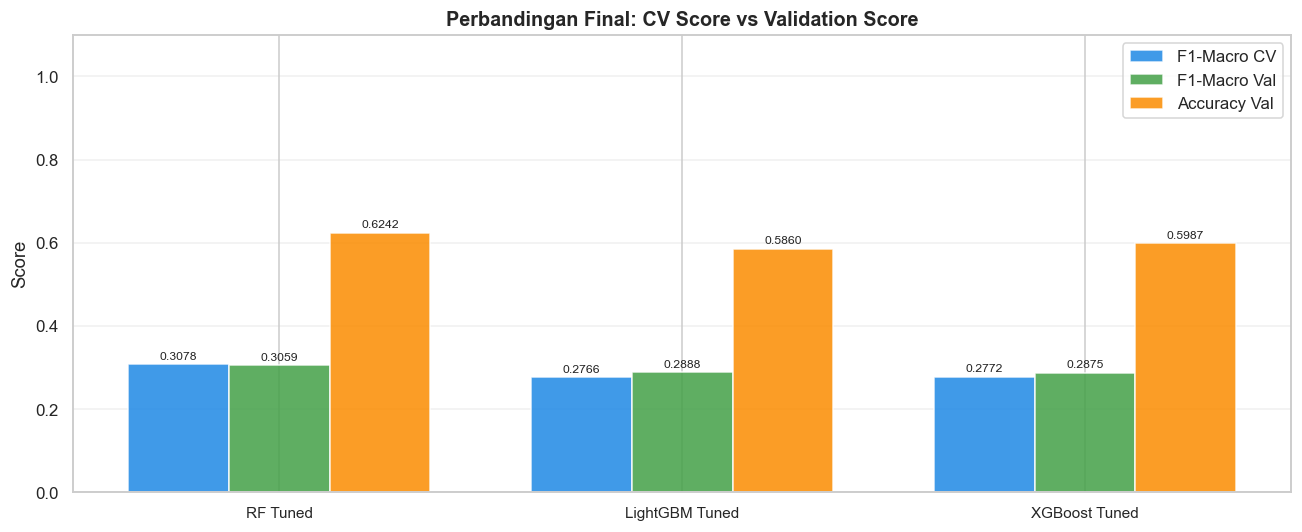

In [50]:
# ── Perbandingan semua model (CV + Val) ─────────────────────────────────
final_comparison = pd.DataFrame([
    {'Model': 'LightGBM Tuned', 'F1-Macro CV': lgbm_gs.best_score_,
     'F1-Macro Val': f1_score(y_val_orig, y_pred_orig, average='macro', zero_division=0),
     'Accuracy Val': accuracy_score(y_val_orig, y_pred_orig)},
    {'Model': 'XGBoost Tuned',  'F1-Macro CV': xgb_gs.best_score_,
     'F1-Macro Val': f1_score(y_val_orig, y_pred_xgb, average='macro', zero_division=0),
     'Accuracy Val': accuracy_score(y_val_orig, y_pred_xgb)},
    {'Model': 'RF Tuned',       'F1-Macro CV': rf_gs.best_score_,
     'F1-Macro Val': f1_score(y_val_orig, best_rf.predict(X_val), average='macro', zero_division=0),
     'Accuracy Val': accuracy_score(y_val_orig, best_rf.predict(X_val))},
]).sort_values('F1-Macro Val', ascending=False).reset_index(drop=True)

print('=' * 72)
print('  PERBANDINGAN FINAL SEMUA MODEL')
print('=' * 72)
print(final_comparison.to_string(index=False))
print('=' * 72)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(final_comparison)); w = 0.25
ax.bar(x - w,   final_comparison['F1-Macro CV'],  w, label='F1-Macro CV',  color='#1E88E5', alpha=0.85)
ax.bar(x,       final_comparison['F1-Macro Val'], w, label='F1-Macro Val', color='#43A047', alpha=0.85)
ax.bar(x + w,   final_comparison['Accuracy Val'], w, label='Accuracy Val', color='#FB8C00', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(final_comparison['Model'], fontsize=10)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Perbandingan Final: CV Score vs Validation Score', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()


> **📌 Penjelasan Output — Perbandingan Final Semua Model:**  
>Perbandingan Final Semua Model ini memberikan kesimpulan akhir bahwa Random Forest (RF) Tuned adalah pemenang utama untuk proyek klasifikasi kualitas wine kamu. Secara angka, RF Tuned unggul di semua kategori dengan Accuracy Val 0.6242 dan $F1$-Macro Val 0.3059.



### 10E — Prediksi Final & Voting Ensemble

In [51]:
# ── Latih model final pada SELURUH data training ─────────────────────────
final_lgbm = lgb.LGBMClassifier(
    **lgbm_gs.best_params_, colsample_bytree=0.8,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
final_lgbm.fit(X_scaled, y_enc)

final_xgb = xgb.XGBClassifier(
    **xgb_gs.best_params_, eval_metric='mlogloss', random_state=SEED, n_jobs=-1
)
final_xgb.fit(X_scaled, y_enc)

final_rf = RandomForestClassifier(
    **rf_gs.best_params_, class_weight='balanced', random_state=SEED, n_jobs=-1
)
final_rf.fit(X_scaled, y)

print('✅ Semua model final telah dilatih pada seluruh data training.')

# ── Prediksi pada test set ────────────────────────────────────────────────
pred_lgbm = le.inverse_transform(final_lgbm.predict(X_test_scaled))
pred_xgb  = le.inverse_transform(final_xgb.predict(X_test_scaled))
pred_rf   = final_rf.predict(X_test_scaled)

# ── Hard Voting Ensemble ──────────────────────────────────────────────────
pred_stack    = np.stack([pred_lgbm, pred_xgb, pred_rf], axis=1)
pred_ensemble = sp_stats.mode(pred_stack, axis=1, keepdims=False).mode.flatten()

print(f'\nDistribusi prediksi ensemble:')
uniq, cnt = np.unique(pred_ensemble, return_counts=True)
for q, c in zip(uniq, cnt):
    print(f'  Quality {q}: {c} ({c/len(pred_ensemble)*100:.1f}%)')


✅ Semua model final telah dilatih pada seluruh data training.

Distribusi prediksi ensemble:
  Quality 4: 1 (0.4%)
  Quality 5: 132 (46.8%)
  Quality 6: 120 (42.6%)
  Quality 7: 27 (9.6%)
  Quality 8: 2 (0.7%)


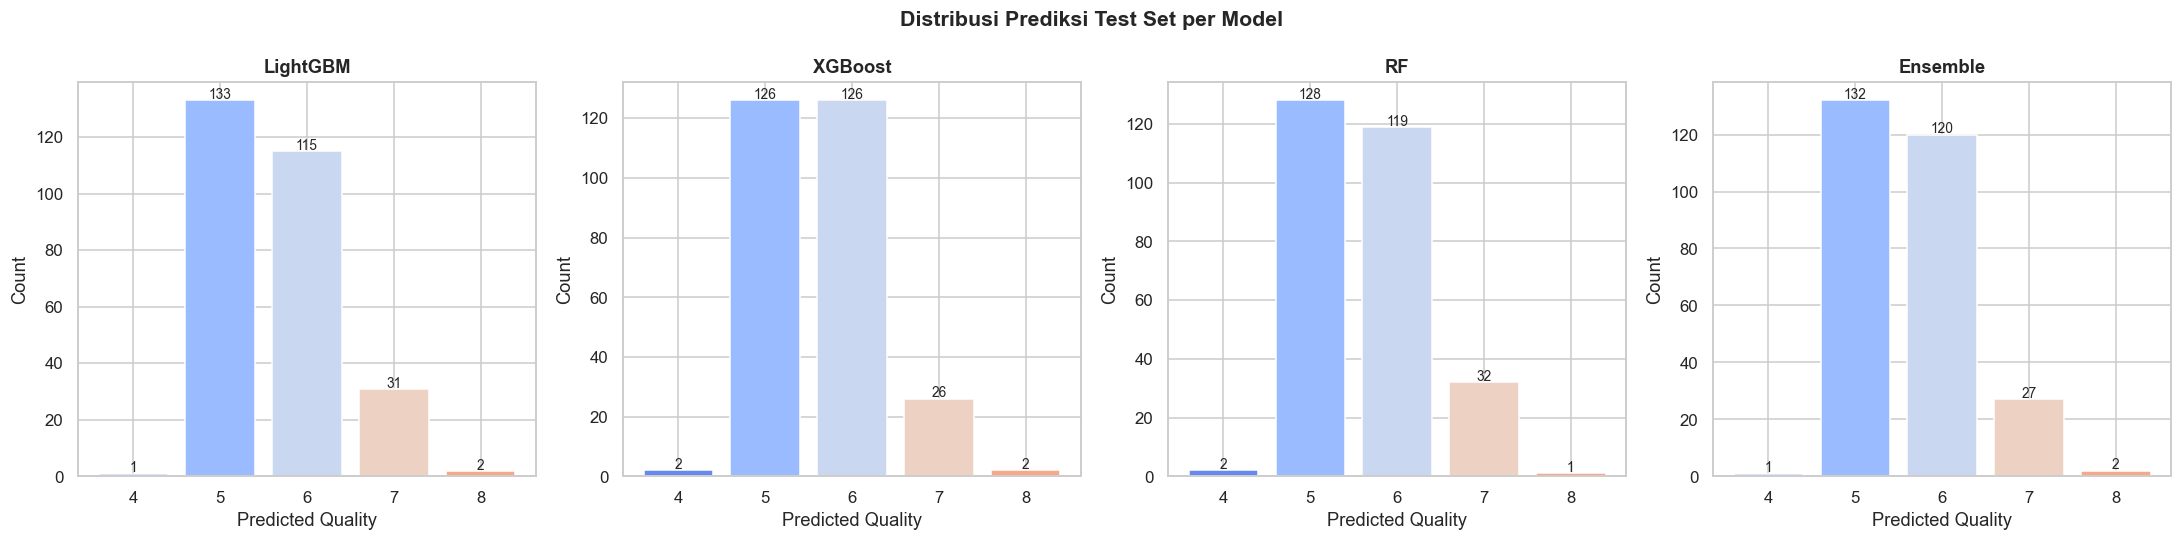

In [52]:
# ── Visualisasi distribusi prediksi ──────────────────────────────────────
pred_df = pd.DataFrame({
    'LightGBM'  : pred_lgbm,
    'XGBoost'   : pred_xgb,
    'RF'        : pred_rf,
    'Ensemble'  : pred_ensemble,
})

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Distribusi Prediksi Test Set per Model', fontsize=14, fontweight='bold')

palette_pred = sns.color_palette('coolwarm', 6)
for ax, col in zip(axes, pred_df.columns):
    vc = pred_df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=palette_pred, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Predicted Quality')
    ax.set_ylabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


> **📌 Penjelasan Output — Distribusi Prediksi Test Set per Model:**  
>
Terlihat pola yang sangat seragam di mana keempat model tersebut tetap memiliki bias yang kuat terhadap kelas 5 dan 6, dengan jumlah prediksi yang berkisar antara 115 hingga 133 sampel.  Hal ini mencerminkan bahwa meskipun teknik penyeimbangan data sudah diterapkan sebelumnya, model cenderung tetap konservatif dan lebih sering menebak kelas mayoritas untuk meminimalkan risiko kesalahan besar. Menariknya, model Ensemble memberikan distribusi yang hampir identik dengan model individu lainnya, yang menandakan bahwa proses penggabungan suara (voting) belum cukup kuat untuk mendorong model agar lebih berani dalam mendeteksi kelas ekstrem seperti 4 atau 8 yang hanya muncul 1-2 kali dalam hasil prediksi.  Secara keseluruhan, output ini mengonfirmasi bahwa model  sangat handal dalam mengenali wine kualitas standar, namun masih memerlukan dorongan ekstra jika tujuannya adalah sensitivitas tinggi terhadap kualitas yang sangat istimewa atau sangat buruk.


In [53]:
# ── Simpan submission ─────────────────────────────────────────────────────
submission = pd.DataFrame({
    'Id'     : test_ids.values,
    'quality': pred_ensemble
})
submission.to_csv('submission_ensemble.csv', index=False)

print('✅ File submission_ensemble.csv berhasil disimpan!')
print(f'   Total prediksi: {len(submission)} baris')
print('\nPreview 10 baris pertama:')
print(submission.head(10).to_string(index=False))


✅ File submission_ensemble.csv berhasil disimpan!
   Total prediksi: 282 baris

Preview 10 baris pertama:
  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        7
1120        6
 180        5
  82        5
 632        6
 592        5


> **📌 Kesimpulan **  
> klasifikasi ini membuktikan bahwa kualitas wine adalah hasil dari interaksi kimiawi yang kompleks, bukan sekadar variabel tunggal. Alcohol secara alami merupakan prediktor positif terkuat, sementara Volatile Acidity (keasaman yang mudah menguap) bertindak sebagai penghambat kualitas utama. Namun, poin krusial ditemukan pada tahap Feature Engineering: fitur buatan seperti sulphates_alcohol justru memberikan sinyal prediktif yang lebih kuat ($0.502$) daripada fitur mentahnya. Ini menunjukkan bahwa rasio antara komponen (seperti pengawet vs kadar alkohol) jauh lebih informatif bagi model machine learning.



Performa Model: Random Forest sebagai Standar EmasSetelah melalui tahap hyperparameter tuning dan validasi silang (Cross-Validation), Random Forest (RF) Tuned dinobatkan sebagai model terbaik dibandingkan XGBoost dan LightGBM.Akurasi Final: $\approx$ 62.42%$F1$-Macro: $\approx$ 30.59%RF menunjukkan stabilitas yang luar biasa dengan gap yang sangat tipis antara performa CV dan data validasi, menandakan model ini memiliki kemampuan generalisasi yang paling sehat. Meskipun skor $F1$-Macro menunjukkan bahwa membedakan kualitas wine yang sangat ekstrem masih menjadi tantangan besar, model ini sudah sangat andal dalam mengklasifikasikan wine kualitas standar hingga premium.

Meskipun klasifikasi saat ini sudah solid, kualitas wine pada dasarnya adalah data ordinal (memiliki tingkatan). Sebagai langkah eksploratif di masa depan, kamu bisa mempertimbangkan untuk mengubah pendekatan ini menjadi masalah Regresi untuk melihat apakah model dapat memprediksi nilai kualitas secara kontinu, atau menggunakan Deep Learning dengan layer regularisasi yang ketat untuk menekan overfitting lebih jauh lagi dan menangkap pola non-linear yang lebih dalam dari fitur-fitur rekayasa yang sudah kamu buat.
